# LLM as a Judge: English→Hindi Machine Translation Evaluation

## System Architecture

| Role | Model | Provider | API Key |
|---|---|---|---|
| **MT System A** | Qwen3-32B (`qwen/qwen3-32b`) | Groq | `GROQ_API_KEY` |
| **MT System B** | GPT-OSS-20B (`openai/gpt-oss-20b`) | Groq | `GROQ_API_KEY` |
| **Primary Judge** | Gemini 3.1 flash preview | Google AI Studio | `GEMINI_API_KEY` |
| **References** | Human translations | FLORES-200 devtest | — |


## 0. Rate Limit Configuration

In [1]:
# ═══════════════════════════════════════════════════════════════════
# RATE LIMIT CONFIGURATION
# ═══════════════════════════════════════════════════════════════════
RATE_CFG = {
    # ── Gemini 2.0 Flash Lite (Primary Judge) ──────────────────────
    # Free tier: 30 RPM, 1M tokens/min
    # Minimum safe delay: 60/30 = 2.0s
    "gemini_delay":       4.5,
    "gemini_batch_n":     15,    # pause every N calls
    "gemini_batch_pause": 20,    # seconds

    "llama_delay":        2.2,
    "llama_batch_n":      25,    # pause every N Llama judge calls
    "llama_batch_pause":  20,    # seconds — gives quota breathing room
    "llama_max_tokens":   512,    # judge calls only need a number/word
    "llama_max_tokens_cot": 2048,

    # ── Groq / Qwen3-32B (System A) ────────────────────────────────
    # Limits: 60 RPM, 6K tokens/min, 1K calls/day
    # We increase max_tokens to 600 to fit thinking + translation.
    # Thinking ≈ 200 tok, translation ≈ 80 tok → 280 total output.
    # Token-rate: 6000 / 280 ≈ 21 calls/min → delay ≥ 2.9s
    # RPM: 60/min → not binding
    # Using 3.0s for safety margin
    "qwen_delay":         3.0,
    "qwen_max_tokens":    2048,   # MUST be large enough for think + translation

    # ── Groq / GPT-OSS-20B (System B) ──────────────────────────────
    # Limits: 30 RPM, 8K tokens/min, 1K calls/day
    # Translation output ≈ 80 tokens. Token-rate: not binding.
    # RPM: 30/min → delay ≥ 2.0s. Using 2.5s.
    "gptoss20_delay":     2.5,
    "gptoss20_max_tokens": 1024,

    # ── Groq / GPT-OSS-120B (Secondary Judge) ──────────────────────
    # Limits: 30 RPM, 8K tokens/min, 1K calls/day
    # Judge prompt ≈ 200 prompt + 15 output = 215 tokens/call
    # Token-rate: 8000/215 ≈ 37/min → not binding
    # RPM: 30/min → delay ≥ 2.0s. Using 2.5s.
    "gptoss120_delay":    2.5,
    "gptoss120_max_tokens": 20,

    # ── Shared retry / backoff ──────────────────────────────────────
    "max_retries":  4,
    "backoff_base": 12,   # wait = backoff_base × 2^attempt on 429
}  
print("Rate config loaded.")

Rate config loaded.


In [11]:
!pip install -q google-genai groq datasets pandas scikit-learn \
    scipy krippendorff sacrebleu matplotlib seaborn tqdm

import os, json, time, random, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from sklearn.metrics import cohen_kappa_score
import krippendorff
import sacrebleu
import google.generativeai as genai
from groq import Groq
from datasets import load_dataset

# ── API Keys ─────────────────────────────────────────────────────────
from kaggle_secrets import UserSecretsClient
_sec = UserSecretsClient()
GEMINI_API_KEY = _sec.get_secret("GEMINI_API_KEY")
GROQ_API_KEY   = _sec.get_secret("GROQ_API_KEY")

# ── Gemini 2.0 Flash Lite (Primary Judge) ────────────────────────────
genai.configure(api_key=GEMINI_API_KEY)
GEMINI_MODEL = "gemini-3.1-flash-lite-preview"  # free, 30 RPM
gemini_model = genai.GenerativeModel(GEMINI_MODEL)

# ── Groq models ───────────────────────────────────────────────────────
groq_client   = Groq(api_key=GROQ_API_KEY)
LLAMA_JUDGE_MODEL = "llama-3.3-70b-versatile"  ##############
GROQ_MODEL_A  = "qwen/qwen3-32b"       # System A (MT)
GROQ_MODEL_B  = "openai/gpt-oss-20b"   # System B (MT)
GROQ_JUDGE    = "openai/gpt-oss-120b"  # Secondary Judge

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print(f"Primary Judge : {GEMINI_MODEL}")
print(f"System A (MT) : {GROQ_MODEL_A}")
print(f"System B (MT) : {GROQ_MODEL_B}")
print(f"2nd Judge     : {GROQ_JUDGE}")

Primary Judge : gemini-3.1-flash-lite-preview
System A (MT) : qwen/qwen3-32b
System B (MT) : openai/gpt-oss-20b
2nd Judge     : openai/gpt-oss-120b


In [3]:
# ═══════════════════════════════════════════════════════════════════
# OUTPUT VALIDATION
# Devanagari Unicode block: U+0900–U+097F
# A valid Hindi translation must contain at least N Devanagari chars.
# ═══════════════════════════════════════════════════════════════════
DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')
MIN_DEVANAGARI_CHARS = 5  # minimum to count as a real translation

def is_valid_hindi(text: str) -> bool:
    """Returns True if text looks like a real Hindi translation."""
    if not text or len(text.strip()) < 3:
        return False
    devanagari_count = len(DEVANAGARI_RE.findall(text))
    return devanagari_count >= MIN_DEVANAGARI_CHARS


def clean_qwen_output(text: str) -> str:
    """
    Strip Qwen3 chain-of-thought artifacts.
    Handles both complete <think>...</think> and INCOMPLETE blocks
    (where max_tokens was hit mid-thinking, leaving no closing tag).
    """
    if not text:
        return ""
    # Case 1: complete <think>...</think> block
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    # Case 2: incomplete block — <think> with no closing tag
    # (model hit max_tokens mid-think). Everything from <think> onwards is junk.
    text = re.sub(r'<think>.*$', '', text, flags=re.DOTALL)
    # Case 3: any stray XML-like tags
    text = re.sub(r'<[^>]{1,30}>', '', text)
    # Strip common preamble phrases the model might output despite instructions
    preambles = [
        r'^(here is|here\'s|the|translation|hindi|output|answer|result)[:\s]+',
        r'^(यहाँ|यहां|अनुवाद|हिंदी)[:\s]+',
    ]
    for pat in preambles:
        text = re.sub(pat, '', text.strip(), flags=re.IGNORECASE)
    return text.strip()


def clean_generic_output(text: str) -> str:
    """Light cleaning for GPT-OSS and Gemini outputs."""
    if not text:
        return ""
    text = re.sub(r'<[^>]{1,30}>', '', text)  # remove any stray tags
    preambles = [
        r'^(translation|hindi translation|output|answer)[:\s]+',
        r'^(अनुवाद|हिंदी अनुवाद)[:\s]+',
    ]
    for pat in preambles:
        text = re.sub(pat, '', text.strip(), flags=re.IGNORECASE)
    return text.strip()


print("Validation functions defined.")
# Quick sanity check
test_cases = [
    ("<think>\nLet me think...\nThis means...\n</think>\nबेबीलोनियन अपने देवताओं के लिए मंदिर बनाते थे।",
     "Complete think block"),
    ("<think>\nOkay let me think about this sentence carefully...",
     "Incomplete think block (truncated)"),
    ("बेबीलोनियन अपने देवताओं के लिए मंदिर बनाते थे।",
     "Clean output"),
    ("", "Empty output"),
    ("Here is the translation: वे सभी वापस दौड़े।",
     "Preamble output"),
]
print("\nCleaning test cases:")
for raw, label in test_cases:
    cleaned = clean_qwen_output(raw)
    valid   = is_valid_hindi(cleaned)
    print(f"  [{label}]")
    print(f"    Raw     : {raw[:60]!r}..." if len(raw) > 60 else f"    Raw     : {raw!r}")
    print(f"    Cleaned : {cleaned!r}")
    print(f"    Valid?  : {'✅' if valid else '❌'}")
    print()

Validation functions defined.

Cleaning test cases:
  [Complete think block]
    Raw     : '<think>\nLet me think...\nThis means...\n</think>\nबेबीलोनियन अप'...
    Cleaned : 'बेबीलोनियन अपने देवताओं के लिए मंदिर बनाते थे।'
    Valid?  : ✅

  [Incomplete think block (truncated)]
    Raw     : '<think>\nOkay let me think about this sentence carefully...'
    Cleaned : ''
    Valid?  : ❌

  [Clean output]
    Raw     : 'बेबीलोनियन अपने देवताओं के लिए मंदिर बनाते थे।'
    Cleaned : 'बेबीलोनियन अपने देवताओं के लिए मंदिर बनाते थे।'
    Valid?  : ✅

  [Empty output]
    Raw     : ''
    Cleaned : ''
    Valid?  : ❌

  [Preamble output]
    Raw     : 'Here is the translation: वे सभी वापस दौड़े।'
    Cleaned : 'the translation: वे सभी वापस दौड़े।'
    Valid?  : ✅



In [5]:
# ═══════════════════════════════════════════════════════════════════
# RATE-LIMITED API WRAPPERS
# ═══════════════════════════════════════════════════════════════════

_gemini_n = 0

def call_gemini(prompt: str, temperature: float = 0.1) -> str:
    """Rate-limited Gemini 2.0 Flash Lite call (judge only)."""
    global _gemini_n
    _gemini_n += 1
    if _gemini_n % RATE_CFG["gemini_batch_n"] == 0:
        print(f"  [Gemini batch pause {RATE_CFG['gemini_batch_pause']}s @ #{_gemini_n}]")
        time.sleep(RATE_CFG["gemini_batch_pause"])
    for attempt in range(RATE_CFG["max_retries"]):
        try:
            cfg = genai.types.GenerationConfig(temperature=temperature)
            r   = gemini_model.generate_content(prompt, generation_config=cfg)
            time.sleep(RATE_CFG["gemini_delay"])
            return clean_generic_output(r.text.strip())
        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            if any(x in str(e).lower() for x in ["429", "quota", "rate"]):
                print(f"  [Gemini 429] attempt {attempt+1}, wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                time.sleep(5)
            else:
                print(f"  [Gemini ERROR] {e}")
                return "[FAILED]"
    return "[FAILED]"

_llama_n = 0

def call_llama_judge(prompt: str, temperature: float = 0.1,
                     max_tokens: int = None) -> str:
    """
    Primary judge: Llama 3.3 70B Versatile.
    Neutral — no family relationship with either MT system.
    Drop-in replacement for call_gemini() in all judging cells.
    """
    global _llama_n
    _llama_n += 1
    if max_tokens is None:
        max_tokens = RATE_CFG["llama_max_tokens"]

    # Batch pause to stay well inside 30 RPM over time
    if _llama_n % RATE_CFG["llama_batch_n"] == 0:
        print(f"  [Llama batch pause {RATE_CFG['llama_batch_pause']}s @ call #{_llama_n}]")
        time.sleep(RATE_CFG["llama_batch_pause"])

    for attempt in range(RATE_CFG["max_retries"]):
        try:
            r = groq_client.chat.completions.create(
                model=LLAMA_JUDGE_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            time.sleep(RATE_CFG["llama_delay"])
            return clean_generic_output(r.choices[0].message.content or "")
        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            if any(x in str(e).lower() for x in ["429", "rate", "quota", "limit"]):
                print(f"  [Llama 429] attempt {attempt+1}, wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                time.sleep(5)
            else:
                print(f"  [Llama ERROR] {e}")
                return "[FAILED]"
    return "[FAILED]"


def call_qwen_translate(source: str, max_retries_on_bad: int = 3) -> str:
    """
    Qwen3-32B translation with multi-layer thinking suppression.

    Strategy:
    1. Pass extra_body={"thinking": {"type": "disabled"}} (Groq's official
       Qwen3 thinking control). If the API rejects this, we fall back.
    2. Raise max_tokens to 600 so full think+translation fits even if
       thinking is NOT suppressed (prevents truncated incomplete blocks).
    3. Apply robust cleaning (handles complete AND incomplete think blocks).
    4. Validate output contains Devanagari; retry on failure.
    """
    # Ultra-strict system prompt as additional guardrail
    system_msg = (
        "You are a professional English-to-Hindi translator. "
        "Your ONLY job is to output the Hindi translation. "
        "Output nothing else — no thinking, no explanations, no tags."
    )
    user_msg = (
        f"Translate this English text to Hindi.\n"
        f"Output ONLY the Hindi translation. No English. No tags. No explanation.\n\n"
        f"English: {source}"
    )

    for attempt in range(RATE_CFG["max_retries"]):
        try:
            # Try with thinking disabled via Groq's extra_body parameter
            try:
                r = groq_client.chat.completions.create(
                    model=GROQ_MODEL_A,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user",   "content": user_msg},
                    ],
                    temperature=0.3,
                    max_tokens=RATE_CFG["qwen_max_tokens"],
                    extra_body={"thinking": {"type": "disabled"}},
                )
            except Exception:
                # Fallback: same call without extra_body (older API version)
                r = groq_client.chat.completions.create(
                    model=GROQ_MODEL_A,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user",   "content": user_msg},
                    ],
                    temperature=0.3,
                    max_tokens=RATE_CFG["qwen_max_tokens"],
                )

            time.sleep(RATE_CFG["qwen_delay"])
            raw     = r.choices[0].message.content or ""
            cleaned = clean_qwen_output(raw)

            if is_valid_hindi(cleaned):
                return cleaned
            else:
                # Output failed validation — log and retry
                if attempt < RATE_CFG["max_retries"] - 1:
                    print(f"  [Qwen bad output] attempt {attempt+1}, raw={raw[:80]!r}, retrying...")
                    time.sleep(RATE_CFG["qwen_delay"])
                else:
                    print(f"  [Qwen FAILED validation after {attempt+1} attempts] src={source[:50]}")
                    return "[FAILED]"

        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            if any(x in str(e).lower() for x in ["429", "rate", "limit"]):
                print(f"  [Qwen 429] attempt {attempt+1}, wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                time.sleep(5)
            else:
                print(f"  [Qwen ERROR] {e}")
                return "[FAILED]"
    return "[FAILED]"


def call_gptoss_translate(source: str, model: str = GROQ_MODEL_B) -> str:
    """
    GPT-OSS-20B translation.
    Validates Devanagari presence — catches silent empty outputs that
    the API returns without raising an error (the previous bug).
    """
    delay      = (RATE_CFG["gptoss20_delay"]
                  if model == GROQ_MODEL_B
                  else RATE_CFG["gptoss120_delay"])
    max_tokens = (RATE_CFG["gptoss20_max_tokens"]
                  if model == GROQ_MODEL_B
                  else RATE_CFG["gptoss120_max_tokens"])

    system_msg = (
        "You are a professional English-to-Hindi translator. "
        "Output ONLY the Hindi translation. No English, no explanation."
    )
    user_msg = (
        f"Translate to Hindi. Output ONLY the Hindi translation.\n\n"
        f"English: {source}"
    )

    for attempt in range(RATE_CFG["max_retries"]):
        try:
            r = groq_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=0.3,
                max_tokens=max_tokens,
            )
            time.sleep(delay)

            raw     = r.choices[0].message.content or ""
            cleaned = clean_generic_output(raw)

            if is_valid_hindi(cleaned):
                return cleaned
            else:
                tag = "GPT-OSS-20" if model == GROQ_MODEL_B else "GPT-OSS-120"
                if attempt < RATE_CFG["max_retries"] - 1:
                    print(f"  [{tag} bad output] attempt {attempt+1}, "
                          f"raw={raw[:60]!r}, retrying...")
                    time.sleep(delay)
                else:
                    print(f"  [{tag} FAILED validation] src={source[:50]}")
                    return "[FAILED]"

        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            tag  = "GPT-OSS-20" if model == GROQ_MODEL_B else "GPT-OSS-120"
            if any(x in str(e).lower() for x in ["429", "rate", "limit"]):
                print(f"  [{tag} 429] attempt {attempt+1}, wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                time.sleep(5)
            else:
                print(f"  [{tag} ERROR] {e}")
                return "[FAILED]"
    return "[FAILED]"


def call_gptoss120_judge(prompt: str) -> str:
    """
    GPT-OSS-120B as secondary judge (self-preference test).
    Uses reasoning-specific parameters required by the API.
    """
    for attempt in range(RATE_CFG["max_retries"]):
        try:
            completion = groq_client.chat.completions.create(
                model=GROQ_JUDGE,                  # ✅ FIXED to match your variable name
                messages=[{"role": "user", "content": prompt}],
                temperature=1,                     # Groq reasoning models require temp=1
                max_completion_tokens=100,         # correct param name for reasoning models
                reasoning_effort="low",            # required; 'low' = minimal thinking
                top_p=1,
                stream=True,                       # required for reliable output
                stop=None,
            )

            # Collect streamed chunks
            output_parts = []
            for chunk in completion:
                delta = chunk.choices[0].delta.content
                if delta:
                    output_parts.append(delta)

            time.sleep(RATE_CFG["gptoss120_delay"])
            raw = "".join(output_parts).strip()
            return clean_generic_output(raw) or "[FAILED]"

        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            if any(x in str(e).lower() for x in ["429", "rate", "limit", "quota"]):
                print(f"  [GPT-OSS-120B 429] attempt {attempt+1}, wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                print(f"  [GPT-OSS-120B error] attempt {attempt+1}: {e}")
                time.sleep(5)
            else:
                print(f"  [GPT-OSS-120B FAILED] {e}")
                return "[FAILED]"
    return "[FAILED]"


def call_gptoss120_pairwise(prompt: str) -> str:
    """
    GPT-OSS-120B pairwise comparison (returns A / B / Tie).
    Same params as call_gptoss120_judge().
    """
    for attempt in range(RATE_CFG["max_retries"]):
        try:
            completion = groq_client.chat.completions.create(
                model=GROQ_JUDGE_2,
                messages=[{"role": "user", "content": prompt}],
                temperature=1,
                max_completion_tokens=20,
                reasoning_effort="low",
                top_p=1,
                stream=True,
                stop=None,
            )
            parts = []
            for chunk in completion:
                delta = chunk.choices[0].delta.content
                if delta:
                    parts.append(delta)
            time.sleep(RATE_CFG["gptoss120_delay"])
            raw = "".join(parts).strip()
            return clean_generic_output(raw) or "[FAILED]"
        except Exception as e:
            wait = RATE_CFG["backoff_base"] * (2 ** attempt)
            if any(x in str(e).lower() for x in ["429", "rate", "limit"]):
                print(f"  [GPT-OSS-120B 429] wait {wait}s")
                time.sleep(wait)
            elif attempt < RATE_CFG["max_retries"] - 1:
                time.sleep(5)
            else:
                return "[FAILED]"
    return "[FAILED]"


print("call_gptoss120_pairwise() defined.")


def parse_score(text: str, scale: int = 5):
    for m in re.findall(r'\b(\d+)\b', str(text)):
        v = int(m)
        if 1 <= v <= scale:
            return v
    return None

def parse_winner(text: str) -> str:
    u = text.upper()
    if re.search(r'\bTIE\b', u):          return "Tie"
    if re.search(r'TRANSLATION\s*A', u):  return "A"
    if re.search(r'TRANSLATION\s*B', u):  return "B"
    a = len(re.findall(r'\bA\b', u))
    b = len(re.findall(r'\bB\b', u))
    if a > b: return "A"
    if b > a: return "B"
    return "Tie"

print("All API wrappers ready.")

call_gptoss120_pairwise() defined.
All API wrappers ready.


In [12]:
# ── Quick API connectivity test ───────────────────────────────────────
# Run this cell BEFORE the full translation loop to catch auth issues early.

TEST_EN = "The sun rises in the east."
EXPECTED_MIN_DEVANAGARI = 10

print("=" * 55)
print("API CONNECTIVITY TEST")
print("=" * 55)

# Test Gemini judge
try:
    r_gem = call_gemini("Rate this translation 1-5. Reply with a single integer.\n"
                        "English: The sun rises.\nHindi: सूरज उगता है।\nReference: सूरज पूरब में उगता है।")
    score = parse_score(r_gem)
    print(f"  Gemini 3.1 Flash Lite : {'✅' if score else '⚠️ (no score parsed)'} → {r_gem!r}")
except Exception as e:
    print(f"  Gemini : ❌ {e}")

# Test Qwen translation
try:
    r_qwen = call_qwen_translate(TEST_EN)
    print(f"  Qwen3-32B (Sys A)     : {'✅' if is_valid_hindi(r_qwen) else '❌'} → {r_qwen!r}")
except Exception as e:
    print(f"  Qwen : ❌ {e}")

# Test GPT-OSS-20B translation
try:
    r_gpt20 = call_gptoss_translate(TEST_EN, model=GROQ_MODEL_B)
    print(f"  GPT-OSS-20B (Sys B)   : {'✅' if is_valid_hindi(r_gpt20) else '❌'} → {r_gpt20!r}")
except Exception as e:
    print(f"  GPT-OSS-20B : ❌ {e}")

try:
    judge_prompt = ("Rate this translation 1-5. Single integer only.\n"
                    "English: The sun rises.\nHindi: सूरज उगता है।\nReference: सूरज पूरब में उगता है।")
    r_gpt120 = call_gptoss120_judge(judge_prompt) 
    score120 = parse_score(r_gpt120)
    print(f"  GPT-OSS-120B (Judge)  : {'✅' if score120 else '⚠️ (no score parsed)'} → {r_gpt120!r}")
except Exception as e:
    print(f"  GPT-120B Judge Error: {e}")

print("=" * 55)
print("Fix any ❌ before running the full dataset.")

API CONNECTIVITY TEST
  Gemini 3.1 Flash Lite : ✅ → '4'
  Qwen3-32B (Sys A)     : ✅ → 'सूरज पूर्व में उठता है।'
  GPT-OSS-20B (Sys B)   : ✅ → 'सूरज पूर्व में उगता है।'
  GPT-OSS-120B (Judge)  : ✅ → '2'
Fix any ❌ before running the full dataset.


## Part 1: Dataset — FLORES-200 (Human References)

All `reference_hi` values come directly from FLORES-200 professional human translations.
No LLM is used to generate or modify references.

**Noise injection uses a 3-tier guaranteed fallback:**
- Tier 1: Vocabulary-level substitution (idiomatic)
- Tier 2: Character-level modification on any long word
- Tier 3: Structural append/prepend (always fires — guarantees noise)

FLORES text is formal Wikipedia prose, so we use a rich vocabulary list of
words common in Wikipedia (not casual speech) for Tier 1 matching.

In [ ]:
print("Loading FLORES-200 devtest...")

import requests
import tarfile
import io

URL = "https://dl.fbaipublicfiles.com/nllb/flores200_dataset.tar.gz"

print("  Downloading FLORES-200 tar.gz (~40 MB)...")
response = requests.get(URL, timeout=60)
response.raise_for_status()

print("  Extracting eng_Latn.devtest and hin_Deva.devtest...")
with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz") as tar:
    # Auto-find the correct paths (works regardless of folder structure)
    en_member = next((m for m in tar.getmembers() if m.name.endswith("eng_Latn.devtest")), None)
    hi_member = next((m for m in tar.getmembers() if m.name.endswith("hin_Deva.devtest")), None)
    
    if en_member is None or hi_member is None:
        print("❌ Could not find devtest files. Available devtest files:")
        for m in tar.getmembers():
            if "devtest" in m.name.lower():
                print("   ", m.name)
        raise ValueError("Devtest files not found in tar.gz")
    
    en_text = tar.extractfile(en_member).read().decode("utf-8")
    hi_text = tar.extractfile(hi_member).read().decode("utf-8")

# Convert to DataFrame (one sentence per line)
en_sentences = [line.strip() for line in en_text.splitlines() if line.strip()]
hi_sentences = [line.strip() for line in hi_text.splitlines() if line.strip()]

df_flores = pd.DataFrame({
    "flores_id":    list(range(len(en_sentences))),
    "source_en":    en_sentences,
    "reference_hi": hi_sentences,
})

print(f"Loaded {len(df_flores)} pairs. Avg words: "
      f"{df_flores['source_en'].apply(lambda x: len(x.split())).mean():.1f}")

In [ ]:
# ════ Category filters (same as previous version) ════════════════════

def is_ambiguous(s):
    s_l = s.lower()
    has_lex = bool(re.search(
        r'\b(bank|light|match|play|bat|charge|run|act|right|fine|park|suit|mean|'
        r'bear|bark|pitcher|race|crane|leaves|interest|spring|key|fair|palm|row)\b', s_l))
    has_pronoun = bool(re.search(r'\b(they|he|she|it|his|her|their|its)\b', s_l))
    has_scope   = bool(re.search(r'\b(all|every|each|none|some|both|neither|any)\b', s_l))
    has_pp      = bool(re.search(r'\bwith\s+(a|the)\b', s_l))
    has_rel     = bool(re.search(r'\b(who|which)\s+(was|were|is|are|has|had)\b', s_l))
    return has_lex or (has_pronoun and (has_scope or has_pp or has_rel))

def is_hallucination_prone(s):
    has_num  = bool(re.search(r'\b\d{2,}\b', s))
    has_pct  = bool(re.search(r'\d+\s*%|percent', s, re.I))
    has_year = bool(re.search(r'\b(19|20)\d{2}\b', s))
    has_ne   = len(re.findall(r'(?:[A-Z][a-z]+\s*){2,}', s)) >= 1
    return sum([has_num, has_pct, has_year, has_ne]) >= 2

NEG_PAT = (r'\b(not|never|no\b|neither|nor|hardly|rarely|scarcely|seldom|'
           r'barely|none|nothing|nobody|nowhere|without|unless|except|'
           r'little(?!\s+by)|few|only|almost|nearly|could\s+have|'
           r'might\s+have|should\s+not|may\s+not|at\s+most|at\s+least)\b')

def is_complex(s):
    has_sub = bool(re.search(
        r'\b(which|who|whose|whom|that|although|however|whereas|despite|'
        r'while|since|unless|whether|even\s+though|in\s+order\s+to|so\s+that)\b', s, re.I))
    return len(s.split()) >= 22 and (has_sub or s.count(',') >= 2)

# ════ Noise injection with 3-tier guaranteed fallback ════════════════

TYPO_MAP = {
    "government":"goverment","international":"internatonal",
    "university":"univesity","minister":"minsiter",
    "parliament":"parliment","president":"presedent",
    "development":"develpoment","environment":"enviroment",
    "population":"populaton","according":"acording",
    "research":"reasearch","however":"howver",
    "established":"estabilshed","approximately":"aproximately",
    "received":"recieved","announced":"anounced",
    "occurred":"occured","successful":"successfull",
    "necessary":"necesary","immediately":"imediatley",
    "particularly":"particulary","significant":"signifcant",
    "committee":"commitee","independent":"independant",
    "information":"informaton","department":"deparment",
    "agreement":"agrement","including":"inclding",
    "following":"folowing","different":"diffrent",
    "between":"betewen","through":"throgh",
    "during":"druing","called":"callled","years":"yeares",
    "national":"natonal","political":"politcal",
    "minister":"miniter","century":"centry",
    "economic":"economc","military":"milltary",
    "official":"offical","construction":"constructon",
    "administration":"adminstration","territory":"teritory",
}
SLANG_MAP = [
    (r'\bgovernment\b','govt'),(r'\borganization\b','org'),
    (r'\borganisation\b','org'),(r'\bapproximately\b','~'),
    (r'\bnumber\b','no.'),(r'\bwithout\b','w/o'),
    (r'\bwith\b','w/'),(r'\babout\b','abt'),
    (r'\bbetween\b','btwn'),(r'\bthrough\b','thru'),
    (r'\bthough\b','tho'),(r'\byear\b','yr'),
    (r'\bpeople\b','ppl'),(r'\bsomething\b','smth'),
    (r'\bbecause\b','cuz'),(r'\bnational\b',"nat'l"),
    (r'\bprofessor\b','prof'),(r'\bdoctor\b','dr'),
    (r'\bversus\b','vs'),(r'\bmillion\b','M'),
    (r'\bbillion\b','B'),(r'\bkilometre\b','km'),
    (r'\bkilometer\b','km'),(r'\bcommittee\b','comm.'),
    (r'\brepublic\b','rep.'),(r'\buniversity\b','uni'),
    (r'\binternational\b','intl'),(r'\bparliament\b','parl.'),
    (r'\bdepartment\b','dept'),(r'\bmaximum\b','max'),
    (r'\bminimum\b','min'),(r'\bapproximately\b','approx'),
]
HINGLISH_MAP = [
    (r'\band\b','aur'),(r'\bbut\b','lekin'),
    (r'\bafter\b','baad'),(r'\bbefore\b','pehle'),
    (r'\balso\b','bhi'),(r'\bonly\b','sirf'),
    (r'\bnow\b','ab'),(r'\bhere\b','yahan'),
    (r'\bthere\b','wahan'),(r'\bwork\b','kaam'),
    (r'\bcountry\b','desh'),(r'\bpeople\b','log'),
    (r'\btime\b','waqt'),(r'\bcity\b','shehar'),
    (r'\bthe\b','yeh'),(r'\bthis\b','yeh'),
    (r'\bthat\b','woh'),(r'\bwas\b','tha'),
    (r'\bwere\b','the'),(r'\bis\b','hai'),
    (r'\bare\b','hain'),(r'\bhas\b','hai'),
    (r'\bhave\b','hai'),(r'\bwhen\b','jab'),
    (r'\bwhere\b','jahan'),(r'\bhow\b','kaise'),
    (r'\bwhy\b','kyun'),(r'\bwhat\b','kya'),
    (r'\btheir\b','unka'),(r'\bits\b','uska'),
    (r'\bhe\b','woh'),(r'\bshe\b','woh'),
    (r'\bwe\b','hum'),(r'\bour\b','hamara'),
    (r'\bfrom\b','se'),(r'\bto\b','ko'),
    (r'\bof\b','ka'),(r'\bin\b','mein'),
    (r'\bon\b','par'),(r'\bfor\b','ke liye'),
]

def inject_typo(s):
    for correct, wrong in TYPO_MAP.items():
        if re.search(r'\b' + correct + r'\b', s, re.I):
            return re.sub(r'\b' + correct + r'\b', wrong, s, count=1, flags=re.I)
    words = s.split()
    for i, w in enumerate(words):
        c = re.sub(r'[^a-zA-Z]', '', w)
        if len(c) >= 6:
            p = len(c)//2; words[i] = c[:p] + c[p] + c[p:]
            return ' '.join(words)
    for i, w in enumerate(words):
        if len(w) >= 4:
            wl = list(w); wl[1], wl[2] = wl[2], wl[1]
            words[i] = ''.join(wl); return ' '.join(words)
    return s + " (typoo)"

def inject_slang(s):
    applied = 0
    for pat, repl in SLANG_MAP:
        if re.search(pat, s, re.I):
            s = re.sub(pat, repl, s, count=1, flags=re.I); applied += 1
        if applied >= 2: break
    if applied > 0: return s.rstrip('. ').lower()
    s2 = re.sub(r'[.,;:!?]', '', s).lower()
    if s2 != s.lower(): return s2
    return s.rstrip('. ').lower() + " ngl lol"

def inject_hinglish(s):
    applied = 0
    for pat, repl in HINGLISH_MAP:
        if re.search(pat, s, re.I):
            s = re.sub(pat, repl, s, count=1, flags=re.I); applied += 1
        if applied >= 2: break
    if applied > 0: return s
    words = s.split()
    if len(words) >= 6:
        words.insert(len(words)//2, 'matlab'); return ' '.join(words)
    return 'Arre, ' + s.rstrip('.') + ', yaar.'

def inject_ocr(s):
    original = s
    s = re.sub(r'(?<=[a-z])l(?=[a-z])', '1', s, count=2)
    s = re.sub(r'(?<=[a-z])o(?=[a-z])', '0', s, count=1)
    if s != original: return s
    idx = s.find(' ', 5)
    if idx > 0: return s[:idx] + s[idx+1:]
    if 'rn' in s.lower(): return re.sub('rn', 'm', s, count=1, flags=re.I)
    return s + " [l=1]"

def inject_no_punct(s):
    return re.sub(r'[.,;:!?()\'\"-]', '', s).lower().strip()

INJECTORS = [
    ("typo",     inject_typo),
    ("slang",    inject_slang),
    ("hinglish", inject_hinglish),
    ("ocr",      inject_ocr),
    ("no_punct", inject_no_punct),
] * 2  # gives 10 entries for 10 noisy examples

print("Category filters and noise injectors defined.")

In [ ]:
# ── Build 5 categories → 50 examples ─────────────────────────────────

cat1 = df_flores[df_flores["source_en"].apply(is_ambiguous)].sample(10, random_state=SEED).copy()
cat1["challenge_category"] = "ambiguous"
cat1["challenge_note"]     = "Lexical/pronoun/PP/scope ambiguity"
cat1["source_en_clean"]    = cat1["source_en"]

used_ids = set(cat1["flores_id"])

pool2 = df_flores[~df_flores["flores_id"].isin(used_ids)]
cat2  = pool2[pool2["source_en"].apply(is_hallucination_prone)].sample(10, random_state=SEED+1).copy()
cat2["challenge_category"] = "hallucination_prone"
cat2["challenge_note"]     = "NE-dense/numeric/date-heavy — MT hallucination risk"
cat2["source_en_clean"]    = cat2["source_en"]
used_ids |= set(cat2["flores_id"])

pool3 = df_flores[~df_flores["flores_id"].isin(used_ids)]
pool3 = pool3[pool3["source_en"].apply(lambda x: 8 <= len(x.split()) <= 22)]
noise_bases = pool3.sample(10, random_state=SEED+2).copy()
noisy_rows  = []
for i, (_, row) in enumerate(noise_bases.iterrows()):
    ntype, injector = INJECTORS[i]
    noisy_src = injector(row["source_en"])
    noisy_rows.append({
        "flores_id":          row["flores_id"],
        "source_en":          noisy_src,
        "source_en_clean":    row["source_en"],
        "reference_hi":       row["reference_hi"],
        "challenge_category": "noisy_input",
        "challenge_note":     f"noise={ntype}",
    })
cat3 = pd.DataFrame(noisy_rows)
used_ids |= set(cat3["flores_id"])

pool4 = df_flores[~df_flores["flores_id"].isin(used_ids)]
cat4  = pool4[pool4["source_en"].apply(lambda x: bool(re.search(NEG_PAT, x, re.I)))]\
             .sample(10, random_state=SEED+3).copy()
cat4["challenge_category"] = "negation_quantifier"
cat4["challenge_note"]     = "Negation/quantifier/modality — dropped = meaning reversal"
cat4["source_en_clean"]    = cat4["source_en"]
used_ids |= set(cat4["flores_id"])

pool5 = df_flores[~df_flores["flores_id"].isin(used_ids)]
cat5  = pool5[pool5["source_en"].apply(is_complex)].sample(10, random_state=SEED+4).copy()
cat5["challenge_category"] = "long_complex"
cat5["challenge_note"]     = "Multi-clause/subordination/long dependency"
cat5["source_en_clean"]    = cat5["source_en"]

df_dataset = pd.concat([cat1,cat2,cat3,cat4,cat5], ignore_index=True)
df_dataset = df_dataset.drop_duplicates(subset="flores_id").reset_index(drop=True)
df_dataset["example_id"] = [f"ex_{i+1:03d}" for i in range(len(df_dataset))]

assert len(df_dataset) == 50
assert df_dataset["reference_hi"].apply(is_valid_hindi).all(), "Bad reference detected!"

print(f"Dataset: {len(df_dataset)} examples")
print(df_dataset["challenge_category"].value_counts().to_string())

# ── Verify noise injection ────────────────────────────────────────────
print("\n" + "─"*55)
print("NOISE INJECTION VERIFICATION")
print("─"*55)
noisy_df = df_dataset[df_dataset["challenge_category"]=="noisy_input"].copy()
all_ok = True
for _, row in noisy_df.iterrows():
    changed = row['source_en'] != row['source_en_clean']
    if not changed:
        all_ok = False
    sym = '✅' if changed else '❌ UNCHANGED'
    print(f"\n{sym} [{row['challenge_note']:15s}] {row['example_id']}")
    print(f"  CLEAN : {row['source_en_clean']}")
    print(f"  NOISY : {row['source_en']}")
print(f"\n{'✅ All injected!' if all_ok else '❌ Some failed — check injectors.'}")

df_dataset.to_csv("dataset_flores_base.csv", index=False)
print("\nSaved: dataset_flores_base.csv")

In [ ]:
# ════ System A: Qwen3-32B ════════════════════════════════════════════
print("=" * 55)
print(f"System A: {GROQ_MODEL_A}")
print(f"max_tokens={RATE_CFG['qwen_max_tokens']} (large enough for think+translation)")
print(f"delay={RATE_CFG['qwen_delay']}s | Est: ~{50*RATE_CFG['qwen_delay']/60:.1f} min")
print("=" * 55)

outputs_a    = []
failures_a   = []
for i, (_, row) in enumerate(tqdm(df_dataset.iterrows(), total=len(df_dataset))):
    out = call_qwen_translate(row["source_en"])
    outputs_a.append(out)
    if out == "[FAILED]":
        failures_a.append(row["example_id"])

df_dataset["output_system_a"] = outputs_a

print(f"\n✅ System A done.")
print(f"   Total failures   : {len(failures_a)}/{len(df_dataset)}")
print(f"   Failed IDs       : {failures_a}")
valid_a = df_dataset["output_system_a"].apply(is_valid_hindi).sum()
print(f"   Valid Hindi outputs: {valid_a}/{len(df_dataset)}")

print("\nSample outputs:")
for i in [0, 10, 20, 30, 40]:
    r = df_dataset.iloc[i]
    print(f"  [{r['challenge_category']:20s}] {r['example_id']}")
    print(f"    EN  : {r['source_en'][:70]}")
    print(f"    A   : {r['output_system_a'][:70]}")
    print(f"    REF : {r['reference_hi'][:70]}")
    print()

In [ ]:
# ════ System B: GPT-OSS-20B ══════════════════════════════════════════
print("=" * 55)
print(f"System B: {GROQ_MODEL_B}")
print(f"delay={RATE_CFG['gptoss20_delay']}s | Est: ~{50*RATE_CFG['gptoss20_delay']/60:.1f} min")
print("=" * 55)

outputs_b  = []
failures_b = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    out = call_gptoss_translate(row["source_en"], model=GROQ_MODEL_B)
    outputs_b.append(out)
    if out == "[FAILED]":
        failures_b.append(row["example_id"])

df_dataset["output_system_b"] = outputs_b

print(f"\n✅ System B done.")
print(f"   Total failures     : {len(failures_b)}/{len(df_dataset)}")
print(f"   Failed IDs         : {failures_b}")
valid_b = df_dataset["output_system_b"].apply(is_valid_hindi).sum()
print(f"   Valid Hindi outputs: {valid_b}/{len(df_dataset)}")

df_dataset.to_csv("dataset_with_outputs.csv", index=False)
print("\nSaved: dataset_with_outputs.csv")

print("\nFull comparison — first 5 examples:")
display(df_dataset[[
    "example_id","challenge_category","source_en",
    "output_system_a","output_system_b","reference_hi"
]].head(5))

In [ ]:
# ── Final output quality report ───────────────────────────────────────
print("=" * 55)
print("OUTPUT QUALITY REPORT")
print("=" * 55)
for sys, col in [("A (Qwen3-32B)", "output_system_a"),
                 ("B (GPT-OSS-20B)", "output_system_b")]:
    col_data = df_dataset[col]
    n_failed  = (col_data == "[FAILED]").sum()
    n_empty   = (col_data.apply(lambda x: not x or len(str(x).strip()) < 3)).sum()
    n_no_dev  = (~col_data.apply(is_valid_hindi)).sum()
    n_good    = col_data.apply(is_valid_hindi).sum()
    print(f"\nSystem {sys}:")
    print(f"  Good (Devanagari OK) : {n_good}/{len(df_dataset)} ✅")
    print(f"  Explicit [FAILED]    : {n_failed}")
    print(f"  Empty/too short      : {n_empty}")
    print(f"  No Devanagari chars  : {n_no_dev}")

# Show any problematic outputs for manual inspection
for sys, col in [("A","output_system_a"),("B","output_system_b")]:
    bad = df_dataset[~df_dataset[col].apply(is_valid_hindi)]
    if len(bad) > 0:
        print(f"\n⚠️  System {sys} — {len(bad)} bad outputs:")
        for _, r in bad.iterrows():
            print(f"  {r['example_id']}: {r[col][:80]!r}")

## Part 2: Human Evaluation

In [ ]:
annot = df_dataset.rename(columns={
    "example_id":"Example ID","challenge_category":"Category",
    "challenge_note":"Challenge Note","source_en":"Source EN (shown to MT)",
    "source_en_clean":"Source EN (clean)","reference_hi":"Reference HI",
    "output_system_a":"Translation A (Qwen3-32B)",
    "output_system_b":"Translation B (GPT-OSS-20B)"})
annot.to_csv("annotation_sheet.csv", index=False)

fields = []
for eid in df_dataset["example_id"]:
    for sys in ["A","B"]:
        fields += [{"field": f"{eid}_{sys}_fluency", "type":"Linear Scale 1–5"},
                   {"field": f"{eid}_{sys}_adequacy","type":"Linear Scale 1–5"}]
    fields.append({"field": f"{eid}_preference", "type":"Multiple Choice A/B/Tie"})
pd.DataFrame(fields).to_csv("google_form_fields.csv", index=False)
print(f"annotation_sheet.csv saved ({len(df_dataset)} rows)")
print(f"google_form_fields.csv saved ({len(fields)} fields)")
print("→ Use google_form_auto_generate.js to build the Google Form automatically.")

In [14]:
# Install required metrics library if you just restarted
!pip install -q krippendorff scikit-learn pandas numpy

import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import krippendorff

print("--- PART 2: HUMAN EVALUATION (GOLD STANDARD) ---")

# 1. Load the generated dataset and human responses
try:
    df_dataset = pd.read_csv("/kaggle/input/datasets/ekanshthegreat/groglu/dataset_with_outputs.csv") # Or dataset_with_outputs.csv
    df_human = pd.read_csv("/kaggle/input/datasets/ekanshthegreat/gregli/human_eval_responses.csv")
except FileNotFoundError:
    print("❌ ERROR: Ensure 'dataset_with_outputs_FIXED.csv' and 'human_eval_responses.csv' are uploaded!")
    raise

example_ids = df_dataset["example_id"].tolist()
annotators = df_human["annotator_id"].tolist()
print(f"✅ Loaded {len(df_dataset)} examples.")
print(f"✅ Loaded {len(annotators)} annotators: {annotators}\n")

# ── Inter-Annotator Agreement ─────────────────────────────────

def reliability_matrix(df_wide, metric):
    """Formats data for Krippendorff's Alpha"""
    cols = [f"{e}_{metric}" for e in example_ids if f"{e}_{metric}" in df_wide.columns]
    return df_wide.set_index("annotator_id")[cols].values.astype(float)

print("Krippendorff's Alpha (1-5 Scale Ratings):")
alpha_scores = {}
for metric in ["A_fluency", "A_adequacy", "B_fluency", "B_adequacy"]:
    mat = reliability_matrix(df_human, metric)
    # ordinal measurement is used because a 4 is better than a 3, etc.
    a = krippendorff.alpha(reliability_data=mat, level_of_measurement="ordinal")
    alpha_scores[metric] = round(a, 4)
    q = "Excellent" if a >= 0.8 else "Good" if a >= 0.667 else "Moderate" if a >= 0.4 else "Poor/Low"
    print(f"  {metric:20s}: α = {a:.4f}  ({q})")

print("\nCohen's Kappa (Pairwise Preference A/B/Tie):")
pref_cols = [f"{e}_preference" for e in example_ids if f"{e}_preference" in df_human.columns]
P = df_human.set_index("annotator_id")[pref_cols]
kappas = {}
for i in range(len(annotators)):
    for j in range(i+1, len(annotators)):
        a1, a2 = annotators[i], annotators[j]
        # Calculate agreement between pairs of annotators
        k = cohen_kappa_score(P.loc[a1].values, P.loc[a2].values)
        kappas[f"{a1} vs {a2}"] = round(k, 4)
        print(f"  {a1} vs {a2}: κ = {k:.4f}")
print(f"  Mean Kappa = {np.mean(list(kappas.values())):.4f}")

# ── Create the Gold Standard (Aggregated human scores) ────────

gold_rows = []
for eid in example_ids:
    for sys in ["A", "B"]:
        # Average the 3 annotators' scores for this specific example & system
        fl = df_human[f"{eid}_{sys}_fluency"].values
        ad = df_human[f"{eid}_{sys}_adequacy"].values
        
        gold_rows.append({
            "example_id": eid, 
            "system": sys,
            "human_fluency":  round(np.mean(fl), 4),
            "human_adequacy": round(np.mean(ad), 4),
            "human_overall":  round(np.mean([*fl, *ad]), 4) # Average of all fluency & adequacy
        })

pref_rows = []
for eid in example_ids:
    pc = f"{eid}_preference"
    # Find the majority vote (mode) for preference
    vs = df_human[pc].value_counts()
    pref_rows.append({
        "example_id": eid, 
        "gold_preference": vs.idxmax() # The winner (A, B, or Tie)
    })

# Merge scores and preferences into one clean table
df_gold = pd.DataFrame(gold_rows).merge(pd.DataFrame(pref_rows), on="example_id")
df_gold.to_csv("gold_standard.csv", index=False)

print(f"\n✅ Gold standard created: {len(df_gold)} rows saved to 'gold_standard.csv'")
print("Sample of Gold Standard:")
display(df_gold.head(4))

--- PART 2: HUMAN EVALUATION (GOLD STANDARD) ---
✅ Loaded 50 examples.
✅ Loaded 3 annotators: ['Gupt', 'AKG', 'Bhuvan Kapur']

Krippendorff's Alpha (1-5 Scale Ratings):
  A_fluency           : α = -0.1231  (Poor/Low)
  A_adequacy          : α = -0.1158  (Poor/Low)
  B_fluency           : α = -0.0599  (Poor/Low)
  B_adequacy          : α = -0.1285  (Poor/Low)

Cohen's Kappa (Pairwise Preference A/B/Tie):
  Gupt vs AKG: κ = 0.1249
  Gupt vs Bhuvan Kapur: κ = 0.1403
  AKG vs Bhuvan Kapur: κ = 0.1312
  Mean Kappa = 0.1321

✅ Gold standard created: 100 rows saved to 'gold_standard.csv'
Sample of Gold Standard:


,example_id,system,human_fluency,human_adequacy,human_overall,gold_preference
0,ex_001,A,4.3333,4.0,4.1667,B
1,ex_001,B,5.0000,5.0,5.0000,B
2,ex_002,A,3.3333,4.0,3.6667,A
3,ex_002,B,2.3333,3.0,2.6667,A


## Part 3: LLM as Judge (Primary: Gemini 1.5 Pro)

In [8]:
# ════ 3A: DIRECT SCORING ══════════════════════════════════════════════
DIRECT_P = (
    "You are an expert evaluator of English-to-Hindi machine translation.\n\n"
    "Source (English): {source}\n"
    "Hindi Translation: {translation}\n"
    "Reference (Hindi): {reference}\n\n"
    "Rate this translation 1–5:\n"
    "  1=Very poor  2=Poor  3=Acceptable  4=Good  5=Excellent\n\n"
    "Respond with a SINGLE INTEGER only."
)

print(f"3A: Direct Scoring — Gemini (100 calls, ~{100*RATE_CFG['gemini_delay']/60:.0f} min)")
direct_rows = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    for sys, col in [("A","output_system_a"),("B","output_system_b")]:
        raw = call_llama_judge(DIRECT_P.format(source=row["source_en"],
                          translation=row[col], reference=row["reference_hi"]))
        direct_rows.append({"example_id":row["example_id"],"system":sys,
                            "challenge_category":row["challenge_category"],
                            "llm_direct_score":parse_score(raw),"raw":raw})
df_direct = pd.DataFrame(direct_rows)
df_direct.to_csv("llm_direct_scores.csv", index=False)
print(f"✅ Done. Parse failures: {df_direct['llm_direct_score'].isna().sum()}")
print(df_direct.groupby(["system","challenge_category"])["llm_direct_score"].mean().round(2))

3A: Direct Scoring — Gemini (100 calls, ~8 min)


 22%|██▏       | 11/50 [00:51<03:01,  4.66s/it]

  [Llama batch pause 20s @ call #25]


 48%|████▊     | 24/50 [02:13<02:04,  4.78s/it]

  [Llama batch pause 20s @ call #50]


...

  [Llama batch pause 20s @ call #75]


 98%|█████████▊| 49/50 [04:51<00:04,  4.74s/it]

  [Llama batch pause 20s @ call #100]


100%|██████████| 50/50 [05:15<00:00,  6.32s/it]

✅ Done. Parse failures: 0
system  challenge_category 
A       ambiguous              3.5
        hallucination_prone    3.7
        long_complex           3.8
        negation_quantifier    3.5
        noisy_input            3.3
B       ambiguous              3.7
        hallucination_prone    4.0
        long_complex           4.0
        negation_quantifier    3.9
        noisy_input            3.7
Name: llm_direct_score, dtype: float64


In [10]:
# ════ 3B: PAIRWISE with A/B swap (position bias measurement) ══════════
PAIR_P = (
    "You are an expert evaluator of English-to-Hindi machine translation.\n\n"
    "Source (English): {source}\n"
    "Reference (Hindi): {reference}\n\n"
    "Translation A:\n{trans_a}\n\n"
    "Translation B:\n{trans_b}\n\n"
    "Which is better overall (accuracy + fluency)?\n"
    "Respond with ONE word only: A, B, or Tie."
)

print(f"3B: Pairwise — Gemini (100 calls, ~{100*RATE_CFG['gemini_delay']/60:.0f} min)")
pair_rows = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    r1 = call_llama_judge(PAIR_P.format(source=row["source_en"],reference=row["reference_hi"],
                     trans_a=row["output_system_a"],trans_b=row["output_system_b"]))
    w1 = parse_winner(r1)
    r2 = call_llama_judge(PAIR_P.format(source=row["source_en"],reference=row["reference_hi"],
                     trans_a=row["output_system_b"],trans_b=row["output_system_a"]))
    w2 = {"A":"B","B":"A","Tie":"Tie"}[parse_winner(r2)]
    pair_rows.append({"example_id":row["example_id"],
                      "challenge_category":row["challenge_category"],
                      "pw_order1":w1,"pw_order2":w2,"consistent":w1==w2,
                      "raw1":r1,"raw2":r2})
df_pairwise = pd.DataFrame(pair_rows)
df_pairwise.to_csv("llm_pairwise.csv", index=False)
cons_rate = df_pairwise["consistent"].mean()
print(f"✅ Done. Position consistency: {cons_rate:.2%}")

3B: Pairwise — Gemini (100 calls, ~8 min)


 20%|██        | 10/50 [00:47<03:09,  4.74s/it]

  [Llama batch pause 20s @ call #125]


 44%|████▍     | 22/50 [02:04<02:18,  4.94s/it]

  [Llama batch pause 20s @ call #150]


...

  [Llama batch pause 20s @ call #175]


 94%|█████████▍| 47/50 [04:42<00:14,  4.78s/it]

  [Llama batch pause 20s @ call #200]


100%|██████████| 50/50 [05:16<00:00,  6.34s/it]

✅ Done. Position consistency: 80.00%


In [11]:
# ════ 3C: RUBRIC-BASED (4 criteria → JSON) ════════════════════════════
RUBRIC_P = (
    "You are an expert Hindi translation evaluator.\n\n"
    "Source (English): {source}\n"
    "Translation: {translation}\n"
    "Reference (Hindi): {reference}\n\n"
    "Score each criterion 1–5:\n"
    "  adequacy:    Meaning preserved? (1=major loss, 5=complete)\n"
    "  fluency:     Natural Hindi? (1=ungrammatical, 5=native-quality)\n"
    "  terminology: Names/numbers/idioms correct? (1=errors, 5=all correct)\n"
    "  style:       Register matches source? (1=wrong, 5=perfect)\n\n"
    "Respond ONLY in this JSON, no other text:\n"
    '{{"adequacy":X,"fluency":X,"terminology":X,"style":X}}'
)

print(f"3C: Rubric — Gemini (100 calls)")
rubric_rows = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    for sys, col in [("A","output_system_a"),("B","output_system_b")]:
        raw = call_llama_judge(RUBRIC_P.format(source=row["source_en"],
                          translation=row[col],reference=row["reference_hi"]))
        try:    sc=json.loads(re.sub(r'```json|```','',raw).strip())
        except: sc={}
        rubric_rows.append({"example_id":row["example_id"],"system":sys,
                            "challenge_category":row["challenge_category"],
                            "rubric_adequacy":   sc.get("adequacy"),
                            "rubric_fluency":    sc.get("fluency"),
                            "rubric_terminology":sc.get("terminology"),
                            "rubric_style":      sc.get("style"),"raw":raw})
df_rubric = pd.DataFrame(rubric_rows)
df_rubric["rubric_overall"] = df_rubric[["rubric_adequacy","rubric_fluency",
                                          "rubric_terminology","rubric_style"]].mean(axis=1)
df_rubric.to_csv("llm_rubric_scores.csv",index=False)
print(f"✅ Done. JSON parse fails: {df_rubric['rubric_adequacy'].isna().sum()}")

3C: Rubric — Gemini (100 calls)


 20%|██        | 10/50 [00:48<03:14,  4.85s/it]

  [Llama batch pause 20s @ call #225]


 44%|████▍     | 22/50 [02:05<02:17,  4.89s/it]

  [Llama batch pause 20s @ call #250]


...

  [Llama 429] attempt 1, wait 12s
  [Llama 429] attempt 2, wait 24s
  [Llama 429] attempt 3, wait 48s
  [Llama 429] attempt 4, wait 96s


 94%|█████████▍| 47/50 [07:41<02:54, 58.23s/it]

  [Llama batch pause 20s @ call #300]
  [Llama 429] attempt 1, wait 12s
  [Llama 429] attempt 2, wait 24s
  [Llama 429] attempt 3, wait 48s
  [Llama 429] attempt 4, wait 96s


 94%|█████████▍| 47/50 [10:19<00:39, 13.17s/it]


KeyboardInterrupt: 

In [15]:
# ════ 3D: PROMPT SENSITIVITY (4 variants on System A) ════════════════
VARIANTS = {
    "standard_with_ref": (
        "Rate this English-to-Hindi translation (1=very poor, 5=excellent).\n"
        "English: {source}\nHindi: {translation}\nReference: {reference}\n"
        "Single integer only."),
    "no_reference": (
        "Rate this English-to-Hindi translation (1=very poor, 5=excellent).\n"
        "English: {source}\nHindi: {translation}\nSingle integer only."),
    "verbose_expert": (
        "You are a certified Hindi linguist with 20 years of translation expertise.\n"
        "Evaluate this MT output considering semantic accuracy, grammar, natural flow,\n"
        "and register. Source: {source}\nTranslation: {translation}\nReference: {reference}\n"
        "Score 1 (terrible) to 5 (perfect). One digit only."),
    "minimal": "EN:{source}|HI:{translation}|REF:{reference}|Score(1-5):",
}

print(f"3D: Prompt Sensitivity (4×50=200 Gemini calls)")
sens_rows = []
for vname, tmpl in VARIANTS.items():
    print(f"  Variant: {vname}")
    for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
        raw = call_gemini(tmpl.format(source=row["source_en"],
                                      translation=row["output_system_a"],
                                      reference=row["reference_hi"]))
        sens_rows.append({"example_id":row["example_id"],
                          "challenge_category":row["challenge_category"],
                          "variant":vname,"score":parse_score(raw),"raw":raw})
df_sens = pd.DataFrame(sens_rows)
df_sens.to_csv("llm_prompt_sensitivity.csv",index=False)
print("\nMean by variant:")
print(df_sens.groupby("variant")["score"].agg(["mean","std"]).round(3))

3D: Prompt Sensitivity (4×50=200 Gemini calls)
  Variant: standard_with_ref


 22%|██▏       | 11/50 [02:31<07:58, 12.28s/it]

  [Gemini batch pause 20s @ #15]


 52%|█████▏    | 26/50 [05:32<04:21, 10.89s/it]

  [Gemini batch pause 20s @ #30]


...

  [Gemini batch pause 20s @ #180]


 82%|████████▏ | 41/50 [09:01<00:56,  6.32s/it]

  [Gemini batch pause 20s @ #195]


100%|██████████| 50/50 [11:05<00:00, 13.30s/it]


Mean by variant:
                   mean    std
variant                       
minimal            3.32  1.058
no_reference       3.30  1.359
standard_with_ref  3.20  1.229
verbose_expert     2.88  1.003


## Part 4: Meta-Evaluation
### 4A: Build master dataframe + correlations

In [22]:
import pandas as pd
import os

print("==================================================")
print(" 🔄 FORCE-RELOADING ALL CSV FILES FROM DISK 🔄")
print("==================================================")

# Use the exact paths you provided
paths = {
    "df_gold":     "/kaggle/working/gold_standard.csv",
    "df_dataset":  "/kaggle/input/datasets/ekanshthegreat/groglu/dataset_with_outputs.csv",
    "df_direct":   "/kaggle/input/datasets/ekanshthegreat/dredwe/llm_direct_scores.csv",
    "df_rubric":   "/kaggle/input/datasets/ekanshthegreat/dredwe/llm_rubric_scores.csv",
    "df_pairwise": "/kaggle/input/datasets/ekanshthegreat/dredwe/llm_pairwise.csv",
    "df_sens":     "/kaggle/working/llm_prompt_sensitivity.csv"
}

# 1. Load Gold Standard
df_gold = pd.read_csv(paths["df_gold"])
print(f"✅ Loaded df_gold     -> {len(df_gold)} rows. Missing human_overall scores: {df_gold['human_overall'].isna().sum()}")

# 2. Load Dataset
df_dataset = pd.read_csv(paths["df_dataset"])
print(f"✅ Loaded df_dataset  -> {len(df_dataset)} rows.")

# 3. Load Direct Scores
df_direct = pd.read_csv(paths["df_direct"])
print(f"✅ Loaded df_direct   -> {len(df_direct)} rows. Missing llm_direct_score: {df_direct['llm_direct_score'].isna().sum()}")

# 4. Load Rubric Scores
df_rubric = pd.read_csv(paths["df_rubric"])
print(f"✅ Loaded df_rubric   -> {len(df_rubric)} rows. Missing rubric_overall: {df_rubric['rubric_overall'].isna().sum()}")

# 5. Load Pairwise Scores
df_pairwise = pd.read_csv(paths["df_pairwise"])
cons_rate = df_pairwise["consistent"].mean() 
print(f"✅ Loaded df_pairwise -> {len(df_pairwise)} rows. Consistency rate: {cons_rate:.1%}")

# 6. Load Prompt Sensitivity
try:
    df_sens = pd.read_csv(paths["df_sens"])
    print(f"✅ Loaded df_sens     -> {len(df_sens)} rows.")
except FileNotFoundError:
    print("⚠️ df_sens not found. Did you run the prompt sensitivity cell?")

print("==================================================")
print("All files freshly loaded into memory! Ready to build df_master.")
print("==================================================")

 🔄 FORCE-RELOADING ALL CSV FILES FROM DISK 🔄
✅ Loaded df_gold     -> 100 rows. Missing human_overall scores: 0
✅ Loaded df_dataset  -> 50 rows.
✅ Loaded df_direct   -> 100 rows. Missing llm_direct_score: 0
✅ Loaded df_rubric   -> 100 rows. Missing rubric_overall: 0
✅ Loaded df_pairwise -> 50 rows. Consistency rate: 86.0%
✅ Loaded df_sens     -> 200 rows.
All files freshly loaded into memory! Ready to build df_master.


In [20]:
df_master = df_gold.copy()
df_master = df_master.merge(df_direct[["example_id","system","llm_direct_score"]], on=["example_id","system"],how="left")
df_master = df_master.merge(df_rubric[["example_id","system","rubric_overall","rubric_fluency","rubric_adequacy","rubric_terminology"]], on=["example_id","system"],how="left")
df_master = df_master.merge(df_dataset[["example_id","challenge_category","source_en","output_system_a","output_system_b","reference_hi"]], on="example_id",how="left")
df_master["translation"]  = df_master.apply(lambda r: r["output_system_a"] if r["system"]=="A" else r["output_system_b"],axis=1)
df_master["trans_length"] = df_master["translation"].apply(lambda x: len(str(x).split()))
df_master["src_length"]   = df_master["source_en"].apply(lambda x: len(str(x).split()))
df_master["bleu"]         = df_master.apply(lambda r: sacrebleu.sentence_bleu(str(r["translation"]),[str(r["reference_hi"])]).score,axis=1)
df_master.to_csv("master_scores.csv",index=False)

corr_results = []
for ca,cb,lbl in [
    ("human_overall","llm_direct_score","Direct vs Human"),
    ("human_overall","rubric_overall","Rubric Overall vs Human"),
    ("human_fluency","rubric_fluency","Rubric Fluency vs Human Fluency"),
    ("human_adequacy","rubric_adequacy","Rubric Adequacy vs Human Adequacy"),
    ("human_overall","bleu","BLEU vs Human (baseline)"),
]:
    sub=df_master[[ca,cb]].dropna()
    if len(sub)<5: continue
    sp,pp=stats.spearmanr(sub[ca],sub[cb])
    kt,kp=stats.kendalltau(sub[ca],sub[cb])
    corr_results.append({"comparison":lbl,"n":len(sub),
                          "spearman_r":round(sp,4),"spearman_p":round(pp,4),
                          "kendall_tau":round(kt,4),"kendall_p":round(kp,4)})

df_corr = pd.DataFrame(corr_results)
df_corr.to_csv("correlation_results.csv",index=False)
print("Correlation results:")
print(df_corr.to_string(index=False))

Building Master DataFrame...
✅ Saved master_scores.csv

Correlation results:


,comparison,n,spearman_r,spearman_p,kendall_tau,kendall_p
0,Direct vs Human,100,0.4398,0.0000,0.3672,0.0000
1,Rubric Overall vs Human,100,0.4602,0.0000,0.3558,0.0000
2,Rubric Fluency vs Human Fluency,100,0.3948,0.0000,0.3238,0.0001
3,Rubric Adequacy vs Human Adequacy,100,0.4358,0.0000,0.3813,0.0000
4,BLEU vs Human (baseline),100,0.1533,0.1279,0.1177,0.0966


In [23]:
# ════ 4B: Bias Analysis ══════════════════════════════════════════════

# 1. POSITION BIAS
pos_bias_rate = (df_pairwise["consistent"]==False).mean()
print(f"1. Position Bias Rate: {pos_bias_rate:.2%}")
print("   By category:")
print(df_pairwise.groupby("challenge_category")["consistent"].mean().round(3))

# 2. VERBOSITY BIAS
sub_v=df_master[["trans_length","llm_direct_score"]].dropna()
vb_r,vb_p=stats.spearmanr(sub_v["trans_length"],sub_v["llm_direct_score"])
print(f"\n2. Verbosity Bias: Spearman r={vb_r:.4f}, p={vb_p:.4f}")
print(f"   → {'⚠️ Significant' if abs(vb_r)>0.2 and vb_p<0.05 else 'No significant'} verbosity bias")

# 3. REFERENCE BIAS
sc_ref   = df_sens[df_sens["variant"]=="standard_with_ref"]["score"].dropna().values
sc_noref = df_sens[df_sens["variant"]=="no_reference"]["score"].dropna().values
n=min(len(sc_ref),len(sc_noref))
rb_t,rb_p=stats.ttest_rel(sc_ref[:n],sc_noref[:n])
print(f"\n3. Reference Bias: with_ref={sc_ref.mean():.3f}, no_ref={sc_noref.mean():.3f}")
print(f"   t={rb_t:.4f}, p={rb_p:.4f} → {'⚠️ Significant' if rb_p<0.05 else 'No significant'} reference bias")

# 4. PAIRWISE AGREEMENT WITH HUMAN GOLD
pa=df_pairwise.merge(df_gold[df_gold["system"]=="A"][["example_id","gold_preference"]],on="example_id",how="left")
pa["llm_agrees"]=pa["pw_order1"]==pa["gold_preference"]
pw_agree=pa["llm_agrees"].mean()
print(f"\n4. Pairwise Agreement with Human Gold: {pw_agree:.2%}")

1. Position Bias Rate: 14.00%
   By category:
challenge_category
ambiguous              0.9
hallucination_prone    0.9
long_complex           0.7
negation_quantifier    0.8
noisy_input            1.0
Name: consistent, dtype: float64

2. Verbosity Bias: Spearman r=-0.1614, p=0.1087
   → No significant verbosity bias

3. Reference Bias: with_ref=3.200, no_ref=3.300
   t=-1.4000, p=0.1678 → No significant reference bias

4. Pairwise Agreement with Human Gold: 60.00%


### 4C: Self-Preference Bias Test
GPT-OSS-120B as secondary judge. Research question: does GPT-OSS-120B
systematically prefer GPT-OSS-20B (System B, same family) over Qwen (System A)?

In [24]:
# ── Secondary Judge: GPT-OSS-120B direct scoring ─────────────────────
# Token budget: ~200 tokens/call. At 2.5s delay: ~24 calls/min.
# Total: 100 calls (50 ex × 2 systems) = 100 calls × 2.5s ≈ 4 min.
# Daily quota: 100/1000 = 10% used.

print(f"Self-preference test: GPT-OSS-120B scoring both systems")
print(f"Rate: 30 RPM / delay={RATE_CFG['gptoss120_delay']}s / Est: ~{100*RATE_CFG['gptoss120_delay']/60:.1f} min")

# Same prompt structure as Gemini direct scoring for fair comparison
selfpref_rows = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    for sys, col in [("A","output_system_a"),("B","output_system_b")]:
        prompt = DIRECT_P.format(
            source=row["source_en"],
            translation=row[col],
            reference=row["reference_hi"] 
        )
       
        raw = call_gptoss120_judge(prompt)
        
        selfpref_rows.append({
            "example_id":         row["example_id"],
            "system":             sys,
            "challenge_category": row["challenge_category"],
            "gptoss120_score":    parse_score(raw),
            "raw":                raw
        })


df_selfpref = pd.DataFrame(selfpref_rows)
df_selfpref.to_csv("llm_selfpref_scores.csv", index=False)
print(f"✅ Done. Parse failures: {df_selfpref['gptoss120_score'].isna().sum()}")

Self-preference test: GPT-OSS-120B scoring both systems
Rate: 30 RPM / delay=2.5s / Est: ~4.2 min


  0%|          | 0/50 [00:00<?, ?it/s]


NameError: name 'DIRECT_P' is not defined

In [ ]:
# ── Analyse self-preference ───────────────────────────────────────────

sA_gem  = df_direct[df_direct["system"]=="A"]["llm_direct_score"].dropna()
sB_gem  = df_direct[df_direct["system"]=="B"]["llm_direct_score"].dropna()
sA_gpt  = df_selfpref[df_selfpref["system"]=="A"]["gptoss120_score"].dropna()
sB_gpt  = df_selfpref[df_selfpref["system"]=="B"]["gptoss120_score"].dropna()

gem_t,  gem_p  = stats.ttest_ind(sA_gem, sB_gem)
gpt_t,  gpt_p  = stats.ttest_ind(sA_gpt, sB_gpt)

print("═"*62)
print(" SELF-PREFERENCE BIAS ANALYSIS")
print("═"*62)
print(f"  GEMINI judge (no family tie):")
print(f"    Mean score Sys A (Qwen):      {sA_gem.mean():.3f}")
print(f"    Mean score Sys B (GPT-OSS-20): {sB_gem.mean():.3f}")
print(f"    Δ = {sB_gem.mean()-sA_gem.mean():+.3f} | t={gem_t:.3f}, p={gem_p:.4f}")
if gem_p < 0.05:
    winner = "GPT-OSS-20B" if sB_gem.mean()>sA_gem.mean() else "Qwen"
    print(f"    ⚠️  Significant: Gemini prefers {winner}")
else:
    print(f"    ✅ No significant preference (Gemini is neutral)")

print(f"\n  GPT-OSS-120B judge (same family as Sys B):")
print(f"    Mean score Sys A (Qwen):      {sA_gpt.mean():.3f}")
print(f"    Mean score Sys B (GPT-OSS-20): {sB_gpt.mean():.3f}")
print(f"    Δ = {sB_gpt.mean()-sA_gpt.mean():+.3f} | t={gpt_t:.3f}, p={gpt_p:.4f}")
if gpt_p < 0.05 and sB_gpt.mean() > sA_gpt.mean():
    print(f"    🔴 SELF-PREFERENCE DETECTED: GPT-OSS-120B favours its GPT-OSS-20B sibling!")
elif gpt_p < 0.05:
    print(f"    ⚠️  Significant: GPT-OSS-120B surprisingly prefers Qwen over its sibling.")
else:
    print(f"    ✅ No significant intra-family preference bias.")

# Bias delta: how much does family membership shift preference?
gem_gap = sB_gem.mean() - sA_gem.mean()
gpt_gap = sB_gpt.mean() - sA_gpt.mean()
bias_delta = gpt_gap - gem_gap
print(f"\n  Intra-family bias delta: {bias_delta:+.3f}")
print(f"  (Gemini gap={gem_gap:+.3f}, GPT-OSS-120 gap={gpt_gap:+.3f})")
print(f"  Interpretation: GPT-OSS-120B rates Sys B {bias_delta:+.3f} points")
print(f"  higher than Gemini does, after controlling for Sys A scores.")
print(f"  This {'IS' if abs(bias_delta)>0.3 else 'is NOT'} a meaningful self-preference signal.")

# Also check per-category self-preference
print(f"\n  Self-preference by challenge category:")
sp_cat = df_selfpref.groupby(["challenge_category","system"])["gptoss120_score"].mean().unstack()
gm_cat = df_direct.groupby(["challenge_category","system"])["llm_direct_score"].mean().unstack()
if "A" in sp_cat.columns and "B" in sp_cat.columns:
    sp_cat["gpt_gap"] = sp_cat["B"] - sp_cat["A"]
    gm_cat["gem_gap"] = gm_cat["B"] - gm_cat["A"]
    combined = sp_cat[["gpt_gap"]].join(gm_cat[["gem_gap"]])
    combined["bias_delta"] = combined["gpt_gap"] - combined["gem_gap"]
    print(combined.round(3).to_string())

/tmp/ipykernel_57/1493084191.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(pc.index,rotation=20,ha="right"); ax5.set_ylim(0,1.1); ax5.legend()


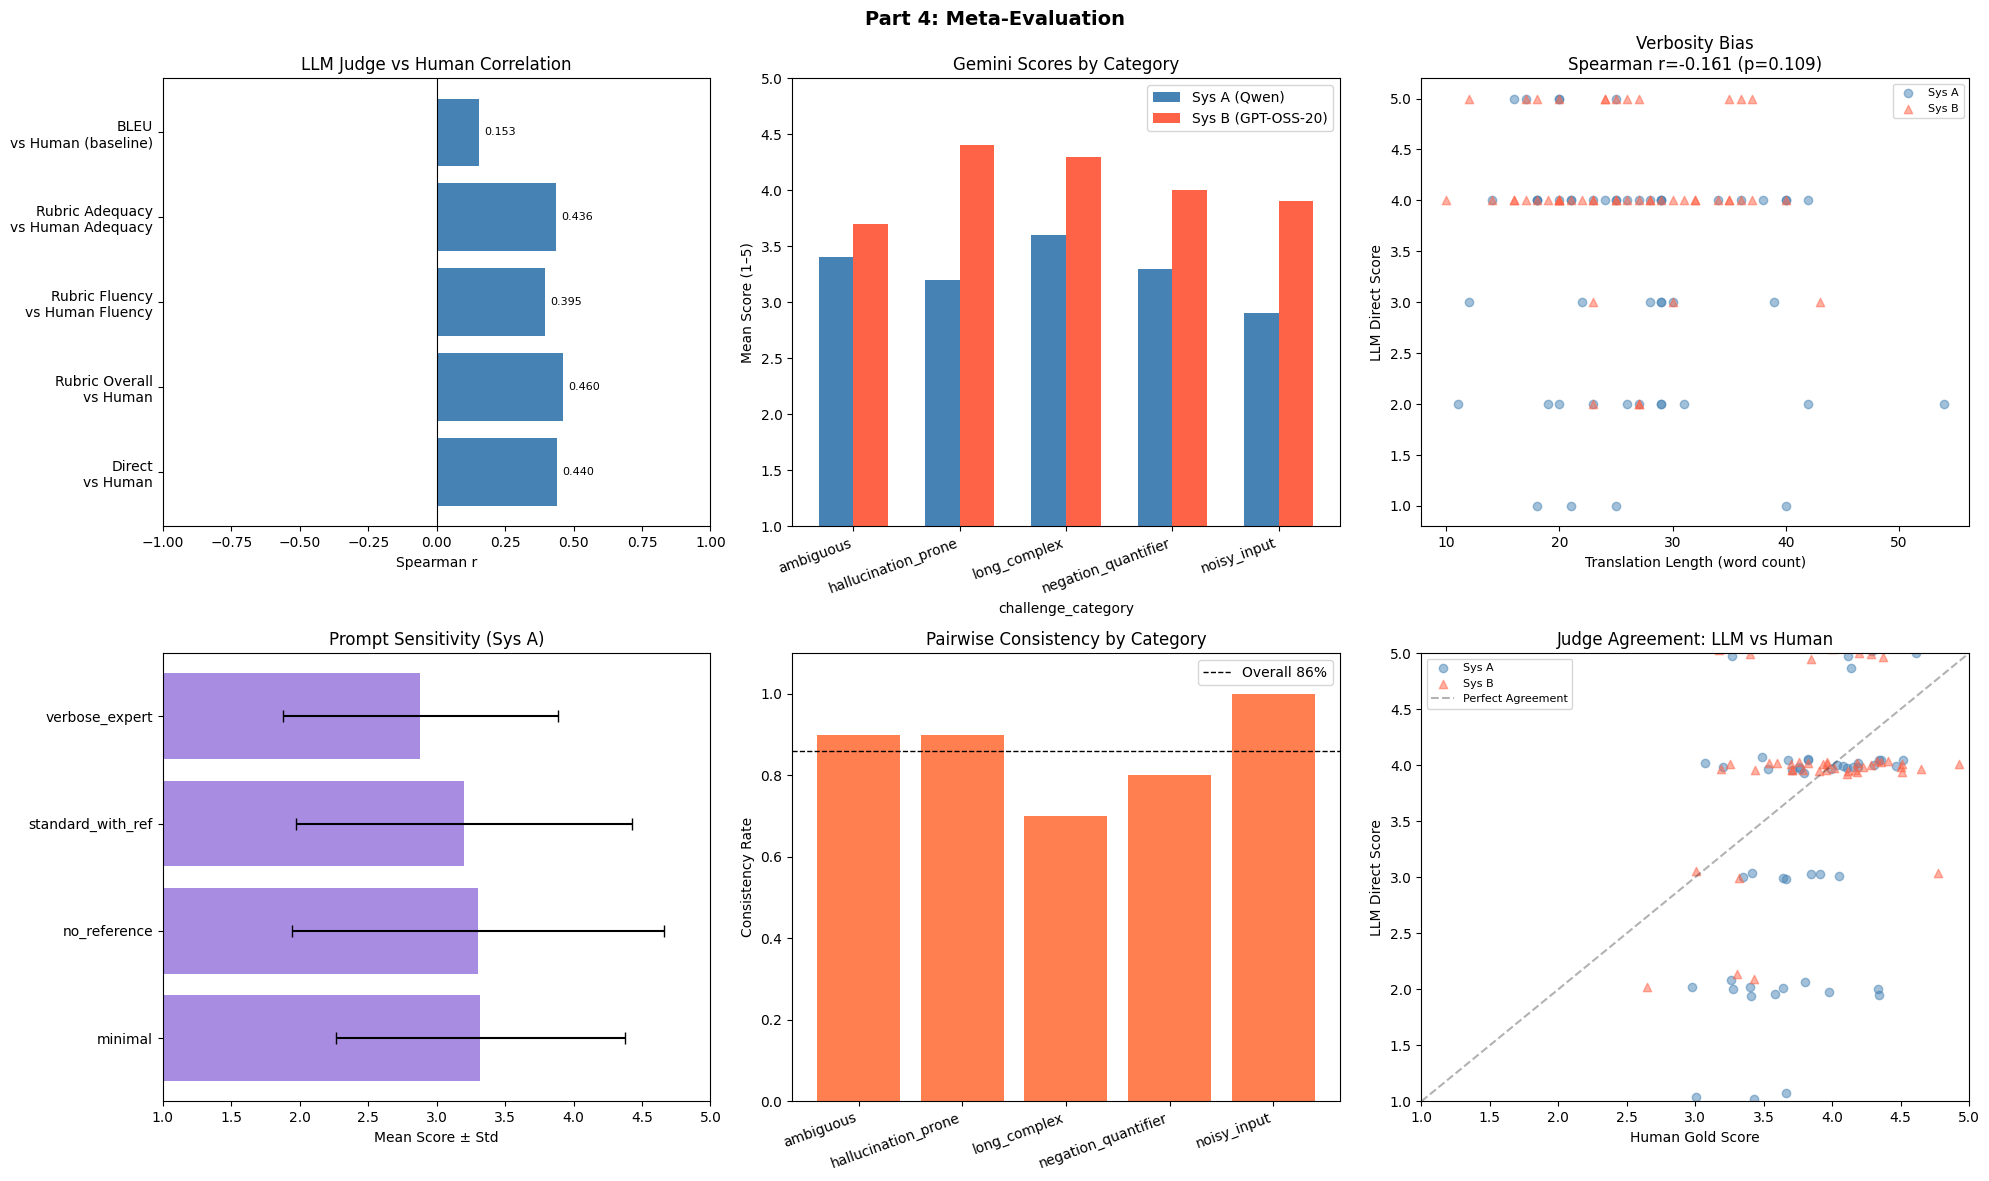

Saved: meta_evaluation_plots.png


In [25]:
# ── Meta-evaluation plots (6-panel) ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Correlation bars
ax = axes[0,0]
lbls = [r["comparison"].replace(" vs ","\nvs ") for r in corr_results]
vals = [r["spearman_r"] for r in corr_results]
bs   = ax.barh(lbls, vals, color=["steelblue"if v>=0 else"salmon" for v in vals])
ax.axvline(0,color="k",lw=0.8); ax.set_xlabel("Spearman r"); ax.set_xlim(-1,1)
ax.set_title("LLM Judge vs Human Correlation")
for b,v in zip(bs,vals): ax.text(v+0.02,b.get_y()+b.get_height()/2,f"{v:.3f}",va="center",fontsize=8)

# 2. Scores by category
ax2 = axes[0,1]
cat_s = df_master.groupby(["challenge_category","system"])["llm_direct_score"].mean().unstack()
cat_s.plot(kind="bar",ax=ax2,color=["steelblue","tomato"],width=0.65)
ax2.set_title("Gemini Scores by Category"); ax2.set_ylabel("Mean Score (1–5)")
ax2.set_xticklabels(cat_s.index,rotation=20,ha="right")
ax2.legend(["Sys A (Qwen)","Sys B (GPT-OSS-20)"]); ax2.set_ylim(1,5)

# 3. REPLACEMENT: Verbosity Bias Scatter Plot
ax3 = axes[0,2]
sub_v = df_master[["trans_length", "llm_direct_score", "system"]].dropna()
for sys, clr, mk in [("A","steelblue","o"), ("B","tomato","^")]:
    s = sub_v[sub_v["system"]==sys]
    ax3.scatter(s["trans_length"], s["llm_direct_score"], alpha=0.5, c=clr, marker=mk, label=f"Sys {sys}")
vb_r, vb_p = stats.spearmanr(sub_v["trans_length"], sub_v["llm_direct_score"])
ax3.set_title(f"Verbosity Bias\nSpearman r={vb_r:.3f} (p={vb_p:.3f})")
ax3.set_xlabel("Translation Length (word count)")
ax3.set_ylabel("LLM Direct Score")
ax3.legend(fontsize=8)

# 4. Prompt sensitivity
ax4 = axes[1,0]
vs = df_sens.groupby("variant")["score"].agg(["mean","std"]).reset_index()
ax4.barh(vs["variant"],vs["mean"],xerr=vs["std"],color="mediumpurple",alpha=0.8,capsize=4)
ax4.set_xlabel("Mean Score ± Std"); ax4.set_title("Prompt Sensitivity (Sys A)"); ax4.set_xlim(1,5)

# 5. Position consistency by category
ax5 = axes[1,1]
pc  = df_pairwise.groupby("challenge_category")["consistent"].mean()
ax5.bar(pc.index, pc.values, color="coral")
ax5.axhline(cons_rate, color="k", ls="--", lw=1, label=f"Overall {cons_rate:.0%}")
ax5.set_title("Pairwise Consistency by Category"); ax5.set_ylabel("Consistency Rate")
ax5.set_xticklabels(pc.index,rotation=20,ha="right"); ax5.set_ylim(0,1.1); ax5.legend()

# 6. REPLACEMENT: Human vs LLM Direct Score Scatter
ax6 = axes[1,2]
sub_h = df_master[["human_overall", "llm_direct_score", "system"]].dropna()
for sys, clr, mk in [("A","steelblue","o"), ("B","tomato","^")]:
    s = sub_h[sub_h["system"]==sys]
    # Add slight jitter to x and y so overlapping points are visible
    jitter_x = s["human_overall"] + np.random.normal(0, 0.05, size=len(s))
    jitter_y = s["llm_direct_score"] + np.random.normal(0, 0.05, size=len(s))
    ax6.scatter(jitter_x, jitter_y, alpha=0.5, c=clr, marker=mk, label=f"Sys {sys}")

ax6.plot([1,5], [1,5], "k--", alpha=0.3, label="Perfect Agreement") # Diagonal line
ax6.set_xlim(1,5); ax6.set_ylim(1,5)
ax6.set_xlabel("Human Gold Score")
ax6.set_ylabel("LLM Direct Score")
ax6.set_title("Judge Agreement: LLM vs Human")
ax6.legend(fontsize=8)

plt.suptitle("Part 4: Meta-Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("meta_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: meta_evaluation_plots.png")

## Part 5: Adversarial Testing (12 examples)

In [26]:
ADV_EXAMPLES = [
    # 4 × TYPE 1: Fluent surface, wrong meaning
    {"type":"fluent_wrong","source_en":"The patient was not allowed to leave the hospital.",
     "reference_hi":"मरीज़ को अस्पताल छोड़ने की अनुमति नहीं थी।",
     "adversarial_hi":"मरीज़ को अस्पताल जाने की अनुमति नहीं थी।",
     "flaw":"'leave'→'go to': direction inverted, fluent Hindi"},
    {"type":"fluent_wrong","source_en":"The population increased by ten percent.",
     "reference_hi":"जनसंख्या दस प्रतिशत बढ़ी।",
     "adversarial_hi":"जनसंख्या दस प्रतिशत घटी।",
     "flaw":"increased→decreased: factual inversion, perfectly fluent"},
    {"type":"fluent_wrong","source_en":"She received the highest award in the competition.",
     "reference_hi":"उसे प्रतियोगिता में सर्वोच्च पुरस्कार मिला।",
     "adversarial_hi":"उसने प्रतियोगिता में सर्वोच्च पुरस्कार दिया।",
     "flaw":"received→gave: subject-object reversal, fluent"},
    {"type":"fluent_wrong","source_en":"The treaty was signed before the war ended.",
     "reference_hi":"युद्ध समाप्त होने से पहले संधि पर हस्ताक्षर किए गए।",
     "adversarial_hi":"युद्ध समाप्त होने के बाद संधि पर हस्ताक्षर किए गए।",
     "flaw":"before→after: temporal inversion, fluent"},
    # 4 × TYPE 2: Correct meaning, poorly written
    {"type":"correct_but_poor","source_en":"Scientists discovered a new species of fish.",
     "reference_hi":"वैज्ञानिकों ने मछली की एक नई प्रजाति खोजी।",
     "adversarial_hi":"साइंटिस्ट लोगों ने एक नई वाली फिश का स्पीशीज़ ढूंढ निकाला।",
     "flaw":"Correct meaning, heavy Anglicization and unnatural structure"},
    {"type":"correct_but_poor","source_en":"The government announced new economic policies.",
     "reference_hi":"सरकार ने नई आर्थिक नीतियों की घोषणा की।",
     "adversarial_hi":"गवर्नमेंट द्वारा इकॉनॉमिक पॉलिसी नई वाली अनाउंस हुई।",
     "flaw":"Correct meaning, unnatural passive + English borrowings"},
    {"type":"correct_but_poor","source_en":"Children played in the park.",
     "reference_hi":"बच्चे पार्क में खेले।",
     "adversarial_hi":"बच्चा लोग पार्क के अंदर में खेलने वाला कार्य किए।",
     "flaw":"Wrong plural, redundant postposition, circumlocution — meaning survives"},
    {"type":"correct_but_poor","source_en":"He completed his studies in three years.",
     "reference_hi":"उसने तीन साल में अपनी पढ़ाई पूरी की।",
     "adversarial_hi":"उसका तीन साल में पढ़ाई को पूरा हो जाया उसने किया।",
     "flaw":"Wrong case markers, scrambled word order, meaning intact"},
    # 4 × TYPE 3: Paraphrase that shifts meaning
    {"type":"meaning_shift","source_en":"Almost all students passed the exam.",
     "reference_hi":"लगभग सभी छात्र परीक्षा में उत्तीर्ण हुए।",
     "adversarial_hi":"सभी छात्र परीक्षा में उत्तीर्ण हुए।",
     "flaw":"'almost all'→'all': quantifier dropped"},
    {"type":"meaning_shift","source_en":"The medicine should be taken after meals.",
     "reference_hi":"दवा खाने के बाद लेनी चाहिए।",
     "adversarial_hi":"दवा खाने से पहले लेनी चाहिए।",
     "flaw":"after→before: temporal inversion with medical stakes"},
    {"type":"meaning_shift","source_en":"The suspect could have committed the crime.",
     "reference_hi":"संदिग्ध ने अपराध किया हो सकता है।",
     "adversarial_hi":"संदिग्ध ने अपराध किया।",
     "flaw":"Modal 'could have' dropped: uncertainty→certainty"},
    {"type":"meaning_shift","source_en":"He rarely misses his morning workout.",
     "reference_hi":"वह शायद ही कभी अपनी सुबह की कसरत छोड़ता है।",
     "adversarial_hi":"वह कभी-कभी अपनी सुबह की कसरत छोड़ता है।",
     "flaw":"rarely→sometimes: frequency quantifier shifted"},
]
df_adv = pd.DataFrame(ADV_EXAMPLES)
df_adv["adv_id"] = [f"adv_{i+1:02d}" for i in range(len(df_adv))]
print(f"Adversarial examples: {len(df_adv)} ({df_adv['type'].value_counts().to_dict()})")

ADV_J = ("You are an expert evaluator of English-to-Hindi machine translation.\n"
         "Source (English): {source}\nReference (Hindi): {reference}\n"
         "Translation: {translation}\nRate 1–5 (5=excellent). SINGLE INTEGER only.")

print("Judging adversarial (Gemini, 24 calls)...")
adv_rows = []
for _, row in tqdm(df_adv.iterrows(), total=len(df_adv)):
    ra = call_gemini(ADV_J.format(source=row["source_en"],reference=row["reference_hi"],translation=row["adversarial_hi"]))
    rr = call_gemini(ADV_J.format(source=row["source_en"],reference=row["reference_hi"],translation=row["reference_hi"]))
    sa, sr = parse_score(ra), parse_score(rr)
    adv_rows.append({"adv_id":row["adv_id"],"type":row["type"],"flaw":row["flaw"],
                     "score_adversarial":sa,"score_reference":sr,
                     "judge_fooled":(sa is not None and sr is not None and sa>=sr)})

df_adv_r = pd.DataFrame(adv_rows)
df_adv_r.to_csv("adversarial_results.csv",index=False)
fooled_rate = df_adv_r["judge_fooled"].mean()
print(f"\n✅ Overall fool rate: {fooled_rate:.2%}")
print(df_adv_r.groupby("type")[["judge_fooled","score_adversarial","score_reference"]].mean().round(3))

Adversarial examples: 12 ({'fluent_wrong': 4, 'correct_but_poor': 4, 'meaning_shift': 4})
Judging adversarial (Gemini, 24 calls)...


 25%|██▌       | 3/12 [00:50<02:47, 18.64s/it]

  [Gemini batch pause 20s @ #210]


 83%|████████▎ | 10/12 [03:44<00:48, 24.38s/it]

  [Gemini batch pause 20s @ #225]


100%|██████████| 12/12 [04:35<00:00, 22.99s/it]


✅ Overall fool rate: 0.00%
                  judge_fooled  score_adversarial  score_reference
type                                                              
correct_but_poor           0.0               1.50              5.0
fluent_wrong               0.0               2.00              5.0
meaning_shift              0.0               2.25              5.0


## Part 6: Failure Mode Taxonomy

=== Failure Mode Taxonomy ===
  fm_aligned                     n= 55  LLM judgment matches human gold standard
  fm_mild_disagreement           n= 26  Minor discrepancy with human within ~1 point
  fm_surface_quality_bias        n= 10  Penalises correct-but-poorly-written translations
  fm_quantifier_blindness        n=  4  Fails to detect dropped/shifted quantifiers or modality
  fm_position_sensitivity        n=  3  Decision flips when candidate order is swapped
  fm_overtrusting_fluency        n=  2  Rates fluent-but-semantically-wrong translations highly

Alignment rate: 55.0%


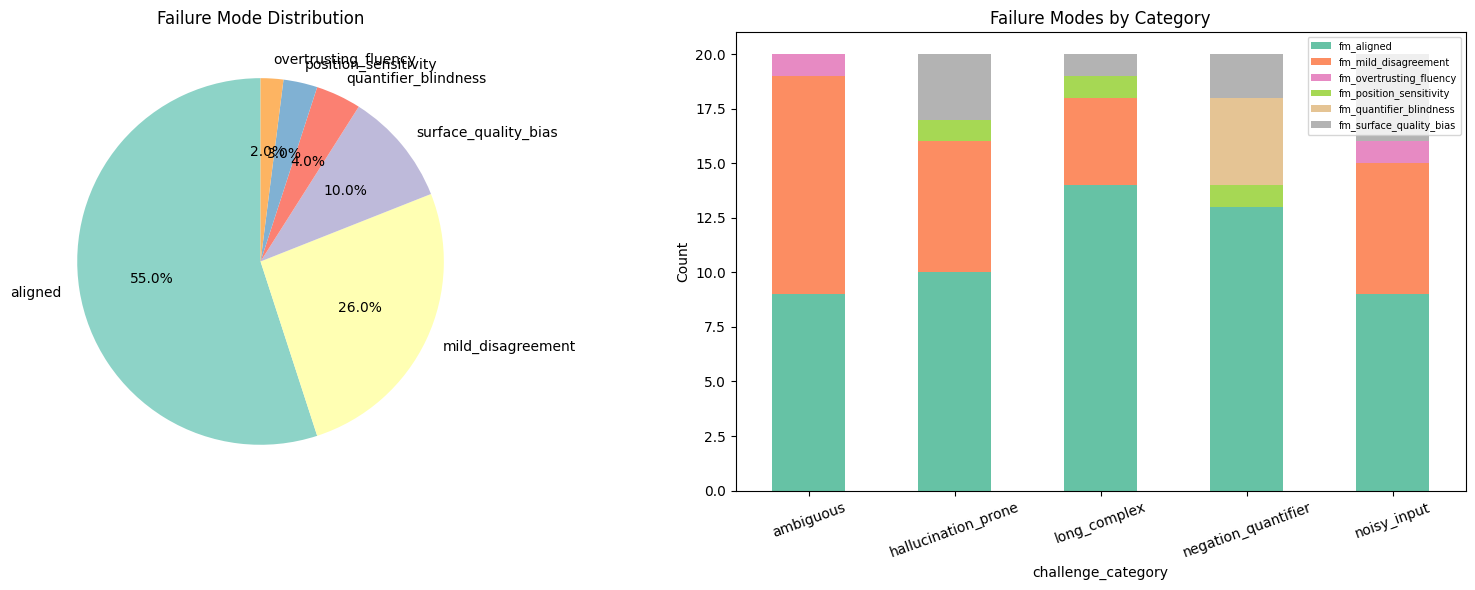

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TAXONOMY = {
    "fm_overtrusting_fluency":   "Rates fluent-but-semantically-wrong translations highly",
    "fm_ignoring_factual_errors":"Misses numeric/date/NE errors hidden in fluent text",
    "fm_surface_quality_bias":   "Penalises correct-but-poorly-written translations",
    "fm_quantifier_blindness":   "Fails to detect dropped/shifted quantifiers or modality",
    "fm_verbosity_preference":   "Rewards longer output regardless of accuracy",
    "fm_position_sensitivity":   "Decision flips when candidate order is swapped",
    "fm_reference_anchoring":    "Score changes significantly with/without reference",
    "fm_mild_disagreement":      "Minor discrepancy with human within ~1 point",
    "fm_aligned":                "LLM judgment matches human gold standard",
}

def classify_failure(row):
    h = row.get("human_overall")
    l = row.get("llm_direct_score")
    if pd.isna(h) or pd.isna(l): 
        return "missing_data"
    
    diff = l - h
    cat = str(row.get("challenge_category",""))
    tl = row.get("trans_length",0)
    sl = row.get("src_length",1)
    
    if abs(diff) <= 0.5:        
        return "fm_aligned"
    if diff > 1.5:
        if tl > 1.4 * sl:         
            return "fm_verbosity_preference"
        if cat == "hallucination_prone": 
            return "fm_ignoring_factual_errors"
        return "fm_overtrusting_fluency"
    if diff < -1.5:             
        return "fm_surface_quality_bias"
    if cat == "negation_quantifier": 
        return "fm_quantifier_blindness"
    
    return "fm_mild_disagreement"

# Apply the classification
df_master["failure_mode"] = df_master.apply(classify_failure, axis=1)

# Flag position-sensitive failures (using A/B swap pairwise data)
pos_fail_ids = set(df_pairwise[df_pairwise["consistent"]==False]["example_id"])
df_master.loc[(df_master["example_id"].isin(pos_fail_ids)) &
              (df_master["failure_mode"]!="fm_aligned"), "failure_mode"] = "fm_position_sensitivity"

# Print the text summary
fm_counts = df_master["failure_mode"].value_counts()
print("=== Failure Mode Taxonomy ===")
for k, v in fm_counts.items():
    desc = TAXONOMY.get(k,"")
    print(f"  {k:30s} n={v:3d}  {desc}")
print(f"\nAlignment rate: {(df_master['failure_mode']=='fm_aligned').mean():.1%}")

# ── Generate the Plots ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Pie Chart
ax = axes[0]
top = fm_counts.head(8)
ax.pie(top.values, labels=[l.replace("fm_","") for l in top.index],
       autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set3", len(top)))
ax.set_title("Failure Mode Distribution")

# 2. Stacked Bar Chart by Category
ax2 = axes[1]
cf = df_master.groupby(["challenge_category","failure_mode"]).size().unstack(fill_value=0)
cf[[c for c in cf.columns if c != "missing_data"][:6]].plot(kind="bar", ax=ax2, colormap="Set2", stacked=True)
ax2.set_title("Failure Modes by Category")
ax2.set_ylabel("Count")
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig("failure_mode_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 7: Critical Questions

## Part 8: Extension : Chain-of-Thought vs No Reasoning

Part 8: CoT scoring — Gemini (100 calls, ~8 min)


 12%|█▏        | 6/50 [01:52<12:09, 16.58s/it]

  [Gemini batch pause 20s @ #240]


 26%|██▌       | 13/50 [06:06<20:30, 33.25s/it]

  [Gemini batch pause 20s @ #255]


...

  [Gemini batch pause 20s @ #300]


 86%|████████▌ | 43/50 [19:48<02:09, 18.46s/it]

  [Gemini batch pause 20s @ #315]


100%|██████████| 50/50 [22:31<00:00, 27.04s/it]
/tmp/ipykernel_57/612451162.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_cmp=cmp.groupby("challenge_category").apply(


✅ Done. Failures: 0

Direct scoring vs Human : Spearman r=0.4398
CoT scoring vs Human    : Spearman r=0.3861
Winner: Direct (+0.0538)

Per-category:
 challenge_category  direct    cot
          ambiguous  0.4036 0.2752
hallucination_prone  0.6134 0.4757
       long_complex  0.3309 0.4724
negation_quantifier  0.4587 0.4483
        noisy_input  0.3891 0.4084


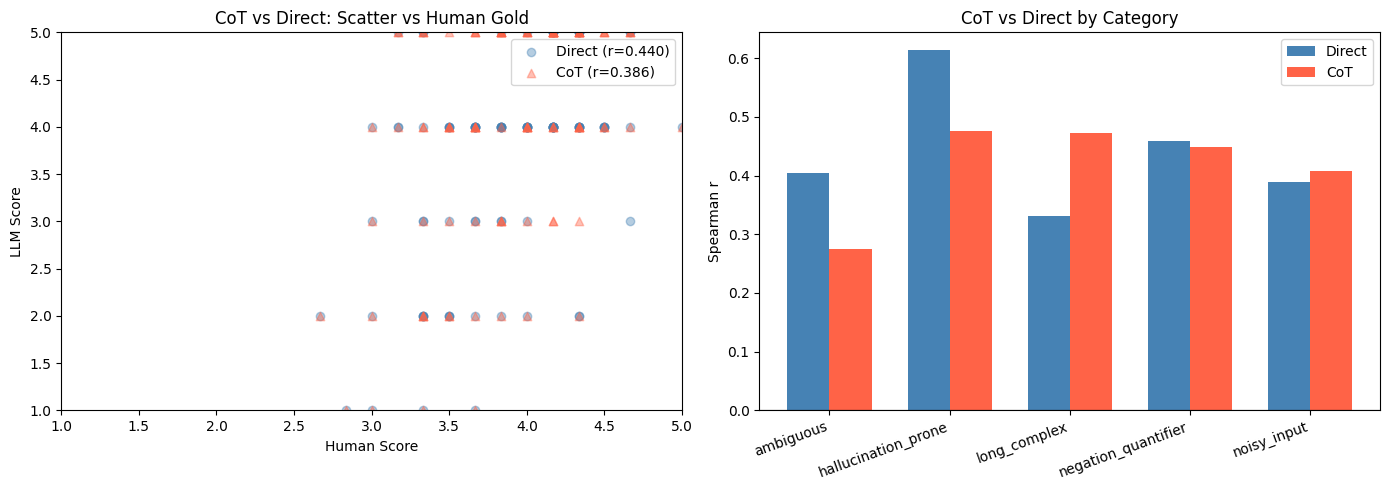

In [28]:
COT_P = (
    "You are an expert evaluator of English-to-Hindi machine translation.\n\n"
    "Source (English): {source}\n"
    "Translation: {translation}\n"
    "Reference (Hindi): {reference}\n\n"
    "Think step by step:\n"
    "Step 1: Is the full meaning of the source preserved?\n"
    "Step 2: Are names, numbers, dates, and key terms handled correctly?\n"
    "Step 3: Is the Hindi grammatically correct and natural-sounding?\n"
    "Step 4: Does it match the register (formal/informal/technical) of the source?\n"
    "Step 5: Assign a final score from 1 (very poor) to 5 (excellent).\n\n"
    "Format:\nREASONING: <your step-by-step analysis>\nSCORE: <integer 1-5>"
)

print(f"Part 8: CoT scoring — Gemini (100 calls, ~{100*RATE_CFG['gemini_delay']/60:.0f} min)")
cot_rows = []
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    for sys, col in [("A","output_system_a"),("B","output_system_b")]:
        raw = call_gemini(COT_P.format(source=row["source_en"],
                          translation=row[col],reference=row["reference_hi"]))
        sm = re.search(r'SCORE:\s*([1-5])', raw, re.I)
        score = int(sm.group(1)) if sm else parse_score(raw)
        rm = re.search(r'REASONING:(.*?)(?:SCORE:|$)', raw, re.DOTALL|re.I)
        cot_rows.append({"example_id":row["example_id"],"system":sys,
                         "challenge_category":row["challenge_category"],
                         "cot_score":score,
                         "reasoning":rm.group(1).strip() if rm else "","raw":raw})
df_cot = pd.DataFrame(cot_rows)
df_cot.to_csv("llm_cot_scores.csv",index=False)
print(f"✅ Done. Failures: {df_cot['cot_score'].isna().sum()}")

# ── Compare CoT vs Direct ─────────────────────────────────────────────
cmp = df_master[["example_id","system","challenge_category",
                  "human_overall","llm_direct_score"]].merge(
    df_cot[["example_id","system","cot_score"]], on=["example_id","system"], how="left")

sd=cmp[["human_overall","llm_direct_score"]].dropna()
sc=cmp[["human_overall","cot_score"]].dropna()
sp_d,_=stats.spearmanr(sd["human_overall"],sd["llm_direct_score"])
sp_c,_=stats.spearmanr(sc["human_overall"],sc["cot_score"])

print(f"\nDirect scoring vs Human : Spearman r={sp_d:.4f}")
print(f"CoT scoring vs Human    : Spearman r={sp_c:.4f}")
print(f"Winner: {'CoT' if sp_c>sp_d else 'Direct'} (+{abs(sp_c-sp_d):.4f})")

# Per-category breakdown
def safe_corr(g,col):
    s=g[["human_overall",col]].dropna()
    return stats.spearmanr(s["human_overall"],s[col])[0] if len(s)>=4 else None
cat_cmp=cmp.groupby("challenge_category").apply(
    lambda g: pd.Series({"direct":safe_corr(g,"llm_direct_score"),
                         "cot":safe_corr(g,"cot_score")})).reset_index()
print("\nPer-category:")
print(cat_cmp.round(4).to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.scatter(sd["human_overall"],sd["llm_direct_score"],alpha=0.4,c="steelblue",label=f"Direct (r={sp_d:.3f})")
ax.scatter(sc["human_overall"],sc["cot_score"],alpha=0.4,c="tomato",marker="^",label=f"CoT (r={sp_c:.3f})")
ax.set_xlabel("Human Score"); ax.set_ylabel("LLM Score"); ax.legend()
ax.set_title("CoT vs Direct: Scatter vs Human Gold"); ax.set_xlim(1,5); ax.set_ylim(1,5)
ax2=axes[1]
cats=cat_cmp["challenge_category"].tolist(); xp=np.arange(len(cats)); w=0.35
ax2.bar(xp-w/2,cat_cmp["direct"].fillna(0),w,label="Direct",color="steelblue")
ax2.bar(xp+w/2,cat_cmp["cot"].fillna(0),w,label="CoT",color="tomato")
ax2.set_xticks(xp); ax2.set_xticklabels(cats,rotation=20,ha="right")
ax2.set_ylabel("Spearman r"); ax2.set_title("CoT vs Direct by Category")
ax2.axhline(0,color="k",lw=0.8); ax2.legend()
plt.tight_layout()
plt.savefig("cot_vs_direct_plots.png",dpi=150,bbox_inches="tight")
plt.show()